Modelo IA para la detección temprana del abandono universitario basado en dataset OULAD

Objetivo del modelo:

Diseñar e implementar un Sistema de Alerta Temprana basado en Inteligencia Artificial que permita predecir el riesgo de abandono en programas universitarios a distancia, mediante la comparación de algoritmos de clasificación supervisada (Random Forest, Árboles de Decisión, XGBoost y Regresión Logística), con el fin de ofrecer a las instituciones educativas una herramienta preventiva para la retención estudiantil.

Autores:


*   Richard Humberto Campos Ballesteros
*   José Andía



# **1. Importación de librerías**

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np
import os

# Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import RocCurveDisplay

# Desbalance de clases
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Librerías para la visualización de la variable objetivo
import matplotlib.pyplot as plt
import seaborn as sns


# **2. Carga del dataset OULAD**

In [2]:
# Install dependencies as needed:
#!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

#Assessments
assessments = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "assessments.csv"
)

#Courses
courses = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "courses.csv"
)

#student_assessment
student_assessments = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "studentAssessment.csv"
)

#student_info
student_info = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "studentInfo.csv"
)

#student_registration
student_registration = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "studentRegistration.csv"
)

#vle
vle = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "vle.csv"
)

#student_vle
student_vle = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "anlgrbz/student-demographics-online-education-dataoulad",
    "studentVle.csv"
)


/tmp/ipykernel_4323/3950185065.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  assessments = kagglehub.load_dataset(


100%|██████████| 8.01k/8.01k [00:00<00:00, 12.1MB/s]
/tmp/ipykernel_4323/3950185065.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  courses = kagglehub.load_dataset(


100%|██████████| 526/526 [00:00<00:00, 263kB/s]
/tmp/ipykernel_4323/3950185065.py:21: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  student_assessments = kagglehub.load_dataset(


100%|██████████| 0.99M/0.99M [00:00<00:00, 38.5MB/s]

Extracting zip of studentAssessment.csv...


...

Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.


/tmp/ipykernel_4323/3950185065.py:42: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  vle = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.


/tmp/ipykernel_4323/3950185065.py:49: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  student_vle = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.


# **3. Fase de análisis de datos (EDA)**

### 3.1. Descripción general de los datasets

--- Assessments DataFrame ---
Shape: (206, 6)
Head:
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               195 non-nul

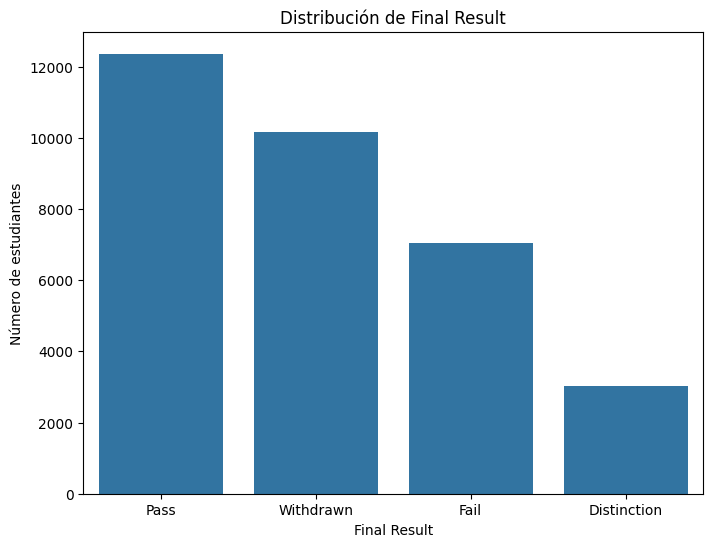


Basado en el objetivo ('abandono'), 'Withdrawn' es la salida clave para la predicción.

### 3.3. Exploración de variable clave y uniones iniciales para predicción temprana
#### 3.3.1. Fusionando información y registro de estudiantes
Encabezado del dataset fusionado 'student_data' (student_info + student_registration):

  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equ

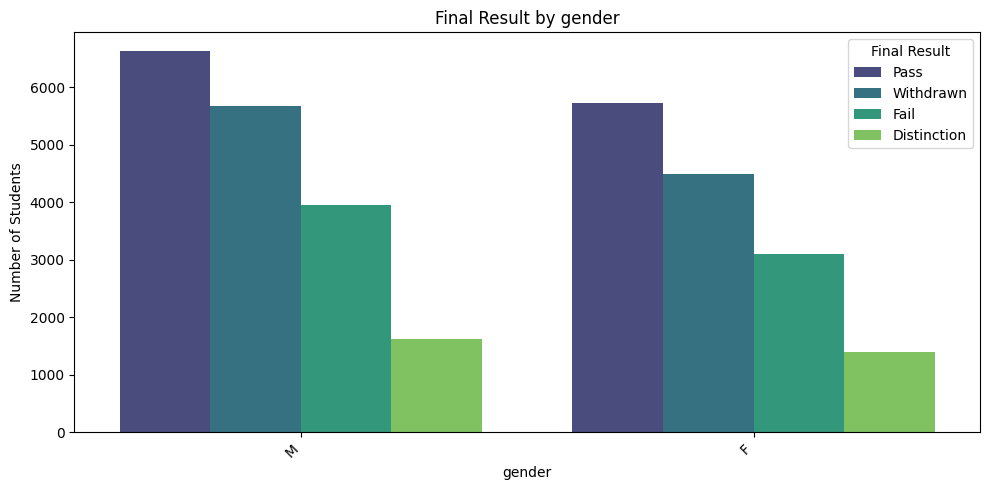

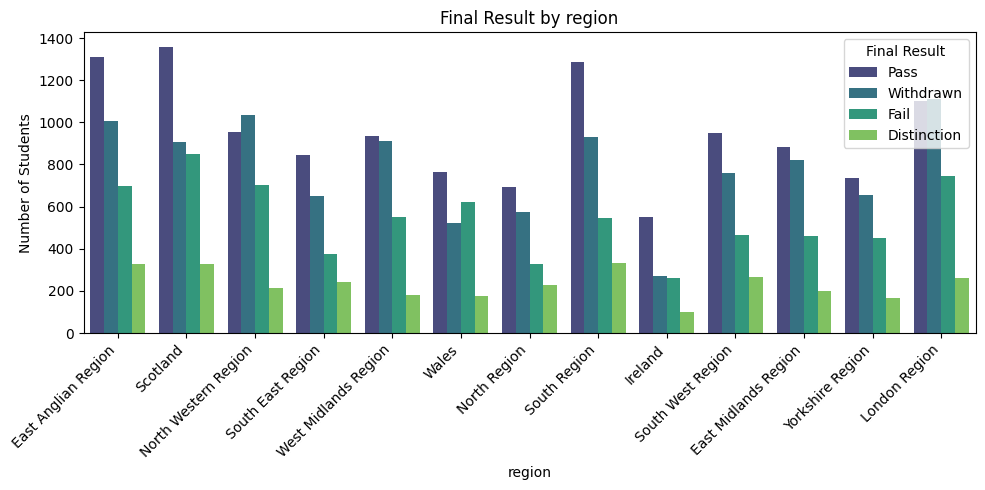

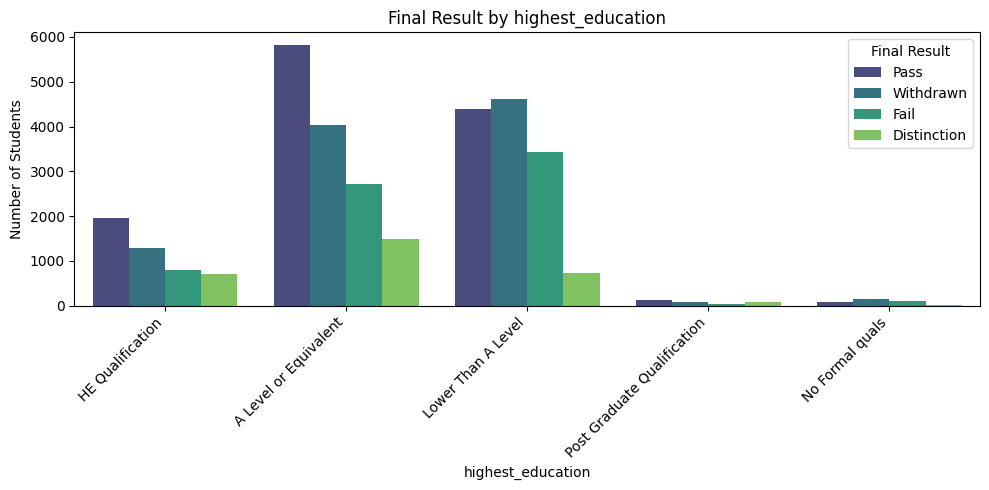

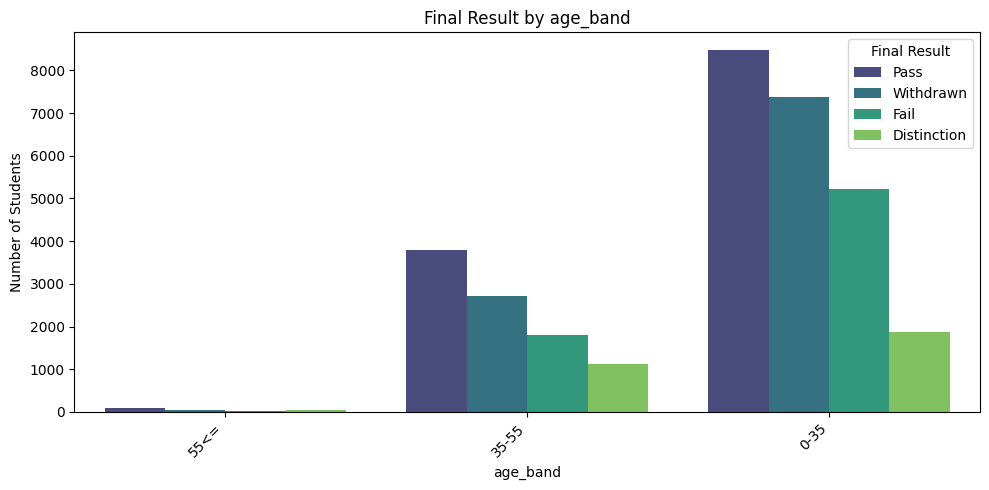

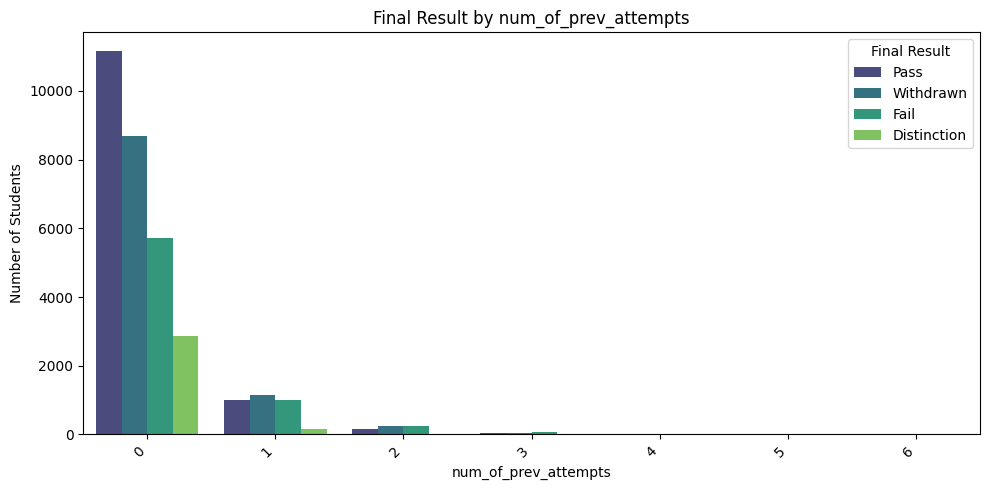

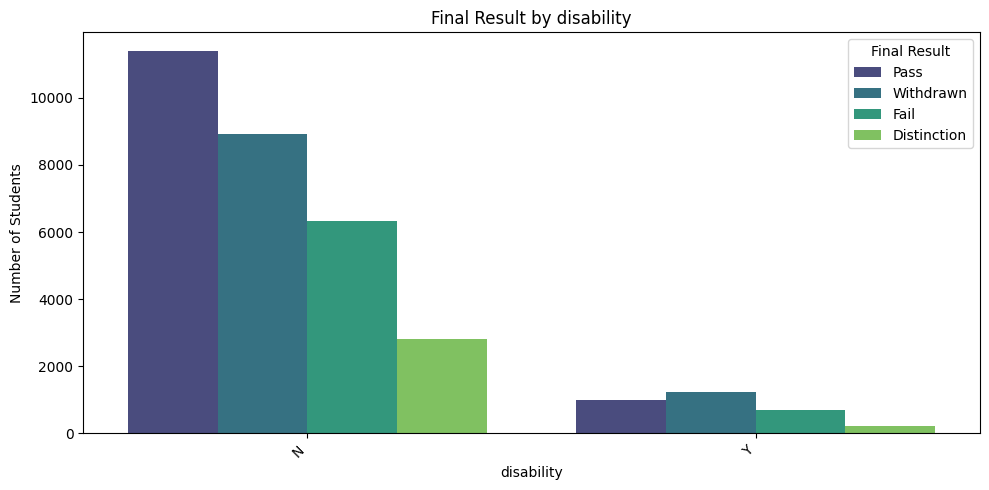

/tmp/ipykernel_4323/728002197.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_data, x='final_result', y='studied_credits', palette='viridis')


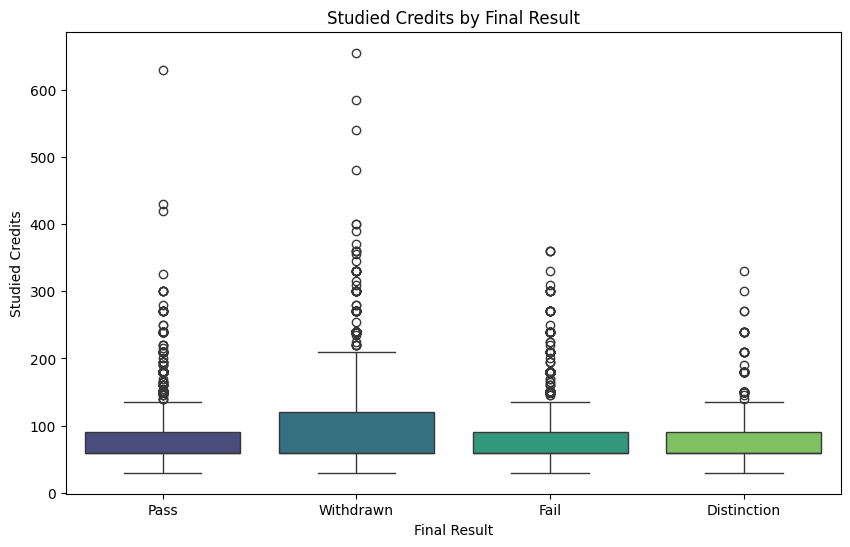


#### 3.3.3. Analizando datos de registro (`date_registration`)


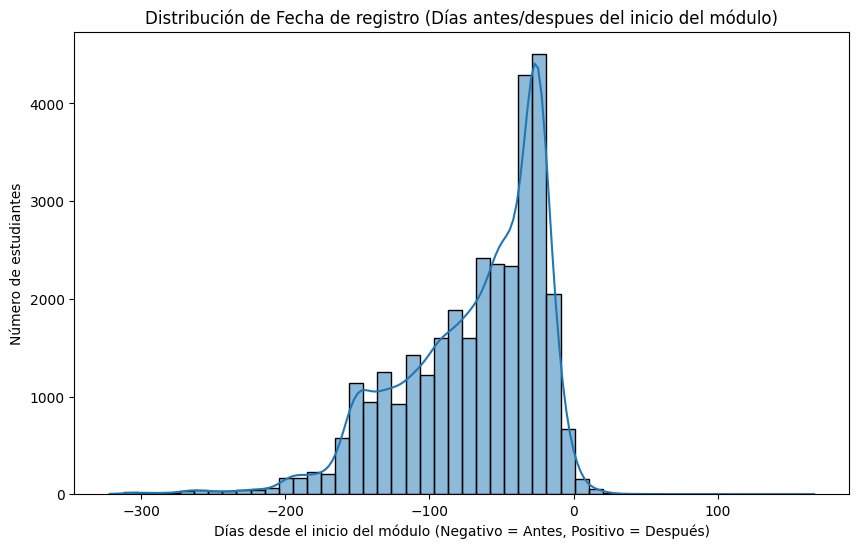

/tmp/ipykernel_4323/728002197.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_data, x='final_result', y='date_registration', palette='viridis')


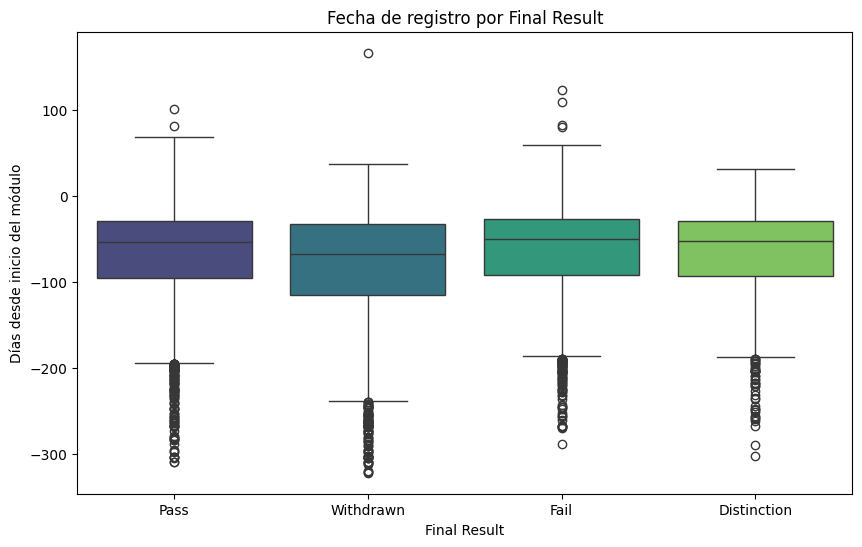


#### 3.3.4. Explorando el desempeño de la evaluación temprana
Encabezado de 'full_assessment_data':
  code_module code_presentation  id_student gender               region  \
0         AAA             2013J       11391      M  East Anglian Region   
1         AAA             2013J       11391      M  East Anglian Region   
2         AAA             2013J       11391      M  East Anglian Region   
3         AAA             2013J       11391      M  East Anglian Region   
4         AAA             2013J       11391      M  East Anglian Region   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification  90-100%     55<=                     0              240   
2  HE Qualification  90-100%     55<=                     0              240   
3  HE Qualification  90-100%     55<=                     0              240   
4  HE Qualification  90-100%     55<=           

/tmp/ipykernel_4323/728002197.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_data, x='final_result', y='early_avg_score', palette='viridis')


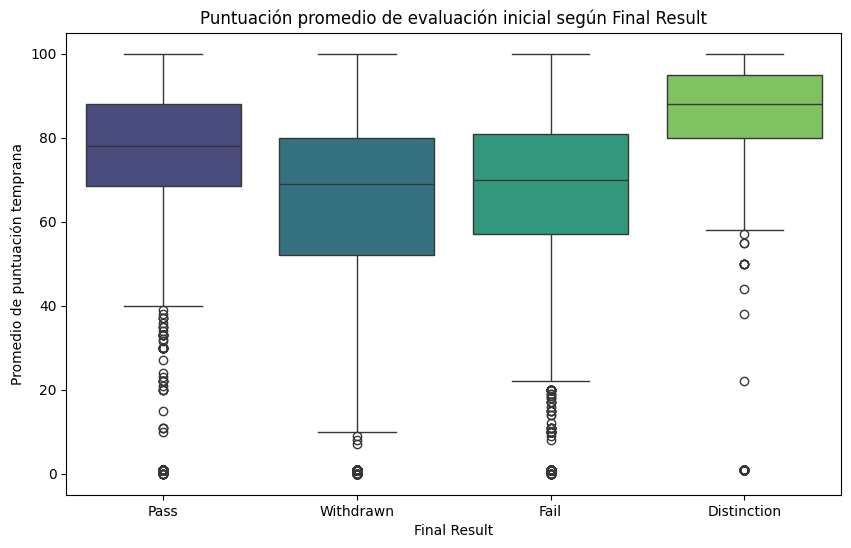


#### 3.3.5. Explorando Actividad VLE temprana
Encabezado de 'full_vle_data':
  code_module code_presentation  id_student gender               region  \
0         AAA             2013J       11391      M  East Anglian Region   
1         AAA             2013J       11391      M  East Anglian Region   
2         AAA             2013J       11391      M  East Anglian Region   
3         AAA             2013J       11391      M  East Anglian Region   
4         AAA             2013J       11391      M  East Anglian Region   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification  90-100%     55<=                     0              240   
2  HE Qualification  90-100%     55<=                     0              240   
3  HE Qualification  90-100%     55<=                     0              240   
4  HE Qualification  90-100%     55<=                     0            

/tmp/ipykernel_4323/728002197.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_data, x='final_result', y='early_total_clicks', palette='viridis')


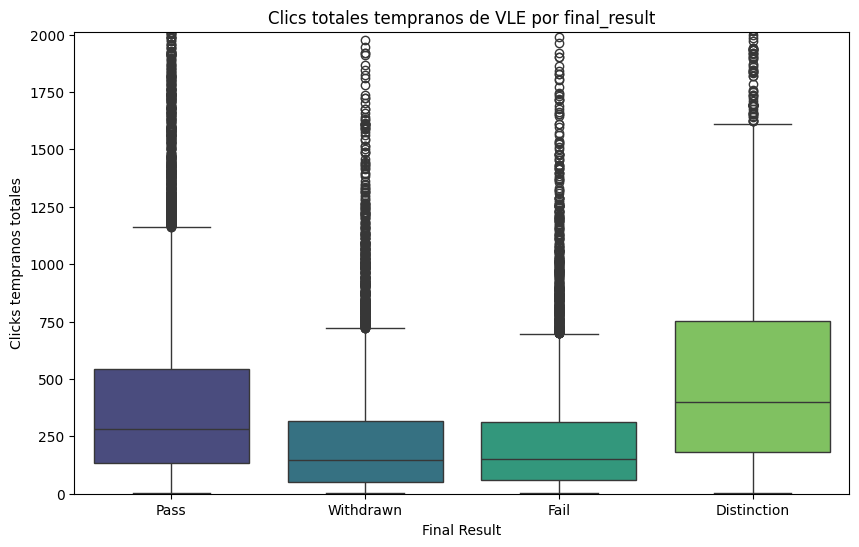


--- EDA Summary and Key Variables for Early Prediction ---
Variables identified as potentially important for early prediction include:
- **Demographic and Background:** gender, region, highest_education, age_band, num_of_prev_attempts, disability, studied_credits. These are available at the start.
- **Registration Behavior:** `date_registration` (how early/late a student registers). This is an early indicator.
- **Early Assessment Performance:** Average scores from assessments taken in the first few weeks/months. This requires monitoring initial academic engagement.
- **Early VLE Engagement:** Total clicks or activity types within the Virtual Learning Environment during the initial period of the course. This also requires monitoring early activity.

Further steps would involve more detailed feature engineering from these raw variables, handling missing values, and preparing the data for model training.


In [3]:
print("### 3.1. Descripción general de los datasets")

# Función para mostrar información básica de cada DataFrame
def display_df_info(df, name):
    print(f"\n--- {name} DataFrame ---")
    print(f"Shape: {df.shape}")
    print(f"Head:\n{df.head()}")
    print(f"\nInfo:")
    df.info()
    # Contando el numero de valores perdidos en cada columna
    print("Número de valores nulos por cada columna")
    print(f"del dataset {name}")
    print("-------"*10)
    nan_count = df.isna().sum()
    # Print the result
    print(nan_count)
    print("-------"*10)
    if df.select_dtypes(include=np.number).columns.any():
        print(f"\nDescription of Numerical Columns:\n{df.describe()}")


display_df_info(assessments, "Assessments")
display_df_info(courses, "Courses")
display_df_info(student_assessments, "Student Assessments")
display_df_info(student_info, "Student Info")
display_df_info(student_registration, "Student Registration")
display_df_info(vle, "VLE")
display_df_info(student_vle, "Student VLE")

print("\n### 3.2. Análisis de la variable objetivo (`final_result`)")
# Se recomienda crear variable 'dropout' y eliminar final_result en el dataset
print("Distribución de 'final_result':")
print(student_info['final_result'].value_counts())
print("\nPorcentaje de distribución de 'final_result':")
print(student_info['final_result'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 6))
sns.countplot(data=student_info, x='final_result', order=student_info['final_result'].value_counts().index)
plt.title('Distribución de Final Result')
plt.xlabel('Final Result')
plt.ylabel('Número de estudiantes')
plt.show()

print("\nBasado en el objetivo ('abandono'), 'Withdrawn' es la salida clave para la predicción.")

print("\n### 3.3. Exploración de variable clave y uniones iniciales para predicción temprana")

print("#### 3.3.1. Fusionando información y registro de estudiantes")
# Se fusionan student_info y student_registration para obtener una vista combinada
# Esta unión es crucial ya que 'final_result' se encuentra en el dataset student_info y 'date_registration' está en el dataset student_registration
student_data = pd.merge(student_info, student_registration,
                        on=['id_student', 'code_module', 'code_presentation'],
                        how='left')

print("Encabezado del dataset fusionado 'student_data' (student_info + student_registration):\n")
print(student_data.head())
print("\nInformación del dataset 'student_data':")
student_data.info()
print("\nValores perdidos en 'student_data':")
print(student_data.isnull().sum()[student_data.isnull().sum() > 0])

print("\n#### 3.3.2. Analizando características demográficas y de antecedentes vs. Final Result")
demographic_cols = ['gender', 'region', 'highest_education', 'age_band', 'num_of_prev_attempts', 'disability']

for col in demographic_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=student_data, x=col, hue='final_result', palette='viridis')
    plt.title(f'Final Result by {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Students')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Final Result')
    plt.tight_layout()
    plt.show()

# Análisis 'studied_credits'
plt.figure(figsize=(10, 6))
sns.boxplot(data=student_data, x='final_result', y='studied_credits', palette='viridis')
plt.title('Studied Credits by Final Result')
plt.xlabel('Final Result')
plt.ylabel('Studied Credits')
plt.show()

print("\n#### 3.3.3. Analizando datos de registro (`date_registration`)")
# 'date_registration' es el número de días antes del inicio de la presentación del módulo.
# Valores negativos significan registro antes del comienzo del módulo, positivos después del inicio.
plt.figure(figsize=(10, 6))
sns.histplot(student_data['date_registration'].dropna(), kde=True, bins=50)
plt.title('Distribución de Fecha de registro (Días antes/despues del inicio del módulo)')
plt.xlabel('Días desde el inicio del módulo (Negativo = Antes, Positivo = Después)')
plt.ylabel('Número de estudiantes')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=student_data, x='final_result', y='date_registration', palette='viridis')
plt.title('Fecha de registro por Final Result')
plt.xlabel('Final Result')
plt.ylabel('Días desde inicio del módulo')
plt.show()

print("\n#### 3.3.4. Explorando el desempeño de la evaluación temprana")
# Se fusiona el dataset student_assessments con assessments para obtener detalles de evaluación
student_assessments_details = pd.merge(student_assessments, assessments,
                                       on='id_assessment', how='left')

# Se fusiona con student_data para enlazar con la variable objetivo final_result (más adelante dropout) y datos demográficos
full_assessment_data = pd.merge(student_data, student_assessments_details,
                                on=['id_student', 'code_module', 'code_presentation'],
                                how='left')

print("Encabezado de 'full_assessment_data':")
print(full_assessment_data.head())
full_assessment_data.info()

# Enfoque en evaluaciones tempranas: Se filtra por evaluaciones realizadas temprano en el módulo(date < 28 días)
early_assessments = full_assessment_data[full_assessment_data['date'] <= 28]

# Se calcula puntuacón promedio para evaulaciones tempranas para cada estudiante
early_avg_scores = early_assessments.groupby(['id_student', 'code_module', 'code_presentation'])['score'].mean().reset_index()
early_avg_scores.rename(columns={'score': 'early_avg_score'}, inplace=True)

# Se fusiona early_avg_scores con el student_data
student_data = pd.merge(student_data, early_avg_scores,
                        on=['id_student', 'code_module', 'code_presentation'],
                        how='left')

plt.figure(figsize=(10, 6))
sns.boxplot(data=student_data, x='final_result', y='early_avg_score', palette='viridis')
plt.title('Puntuación promedio de evaluación inicial según Final Result')
plt.xlabel('Final Result')
plt.ylabel('Promedio de puntuación temprana')
plt.show()

print("\n#### 3.3.5. Explorando Actividad VLE temprana")
# Se fusiona los datasets student_vle y vle para obtener tipos de actividad VLE
student_vle_details = pd.merge(student_vle, vle,
                               on=['id_site', 'code_module', 'code_presentation'],
                               how='left')

# Se fusiona student_data con student_vle_details para conenctar la variable objetivo final_result (dropout)
full_vle_data = pd.merge(student_data, student_vle_details,
                         on=['id_student', 'code_module', 'code_presentation'],
                         how='left')

print("Encabezado de 'full_vle_data':")
print(full_vle_data.head())
full_vle_data.info()

# Enfoque en actividad VLE tremprana: Se filtra por actividad que ocurre temprano en el módulo (date < 28 días)
early_vle_activity = full_vle_data[full_vle_data['date'] <= 28] # date pertenece al dataset student_vle

# Se calcula clicks totales para actividad VLE temprana para cada estudiante
early_total_clicks = early_vle_activity.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().reset_index()
early_total_clicks.rename(columns={'sum_click': 'early_total_clicks'}, inplace=True)

# Se fusiona early_total_clicks con student_data
student_data = pd.merge(student_data, early_total_clicks,
                        on=['id_student', 'code_module', 'code_presentation'],
                        how='left')

plt.figure(figsize=(10, 6))
sns.boxplot(data=student_data, x='final_result', y='early_total_clicks', palette='viridis')
plt.title('Clics totales tempranos de VLE por final_result')
plt.xlabel('Final Result')
plt.ylabel('Clicks tempranos totales')
plt.ylim(0, student_data['early_total_clicks'].quantile(0.99)) # Se recortan outliers para mejor visualización
plt.show()

print("\n--- EDA Summary and Key Variables for Early Prediction ---")
print("Variables identified as potentially important for early prediction include:")
print("- **Demographic and Background:** gender, region, highest_education, age_band, num_of_prev_attempts, disability, studied_credits. These are available at the start.")
print("- **Registration Behavior:** `date_registration` (how early/late a student registers). This is an early indicator.")
print("- **Early Assessment Performance:** Average scores from assessments taken in the first few weeks/months. This requires monitoring initial academic engagement.")
print("- **Early VLE Engagement:** Total clicks or activity types within the Virtual Learning Environment during the initial period of the course. This also requires monitoring early activity.")
print("\nFurther steps would involve more detailed feature engineering from these raw variables, handling missing values, and preparing the data for model training.")

**3.1 Distribución variable objetivo**

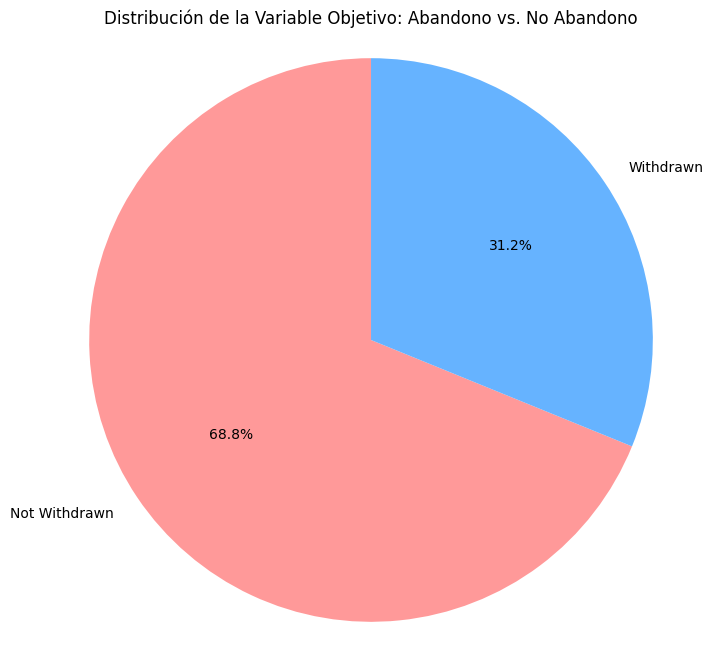

In [4]:
# Crear una nueva variable para agrupar los resultados
student_info['grouped_final_result'] = student_info['final_result'].apply(lambda x: 'Withdrawn' if x == 'Withdrawn' else 'Not Withdrawn')

# Calcular la distribución de la nueva variable
distribution = student_info['grouped_final_result'].value_counts()

# Generar el gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(distribution, labels=distribution.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribución de la Variable Objetivo: Abandono vs. No Abandono')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Opcional: Eliminar la columna temporal si no se necesita más
student_info.drop(columns=['grouped_final_result'], inplace=True)

# **4. Ingeniería de características**

### Unidades Estadísticas y Flujo de Datos en Ingeniería de Características

En este proceso de ingeniería de características, es crucial entender qué representa cada fila en el conjunto de datos en las diferentes etapas. La unidad estadística base para este análisis es la **matrícula única de un estudiante en una presentación de curso específica** (definida por `id_student`, `code_module`, `code_presentation`).

- **Inicio (Base Student Data)**: Cada fila representa una matrícula única. Esto significa que si un estudiante se inscribe en dos cursos diferentes o en el mismo curso en dos presentaciones distintas, tendrá dos filas, cada una representando una matrícula independiente.

- **Características Agregadas**: Cuando se añaden características de evaluaciones o actividad VLE, estas se agrupan por la misma unidad estadística (`id_student`, `code_module`, `code_presentation`). Por lo tanto, el número de filas (matrículas) se mantiene constante a lo largo del proceso, y cada fila sigue siendo una matrícula única con sus características correspondientes.

In [5]:
# --- Ingeniería de Características para Predicción Temprana de Abandono Escolar ---

# --- Base Student Data (pre-merge student_info and student_registration) ---
# Esta es la base común para todas las ventanas temporales
base_student_data = pd.merge(student_info, student_registration,
                             on=['id_student', 'code_module', 'code_presentation'],
                             how='left')

# 2. Definir una ventana temporal para 'predicción temprana': 28 días (4 semanas)
window_days = 28
current_window_week = window_days // 7
print(f"\n--- Procesando para la ventana de {current_window_week} semanas ({window_days} días) ---")

# Crear una copia profunda del DataFrame base para esta ventana
window_student_data = base_student_data.copy()

# Añadir la variable objetivo 'dropout'
window_student_data['dropout'] = window_student_data['final_result'].apply(lambda x: 1 if x == 'Withdrawn' else 0)
window_student_data = window_student_data.drop('final_result', axis=1)

# --- Características de Evaluaciones Tempranas ---
student_assessments_details_temp = pd.merge(student_assessments,
                                       assessments[['id_assessment', 'date', 'assessment_type', 'weight', 'code_module', 'code_presentation']],
                                       on='id_assessment',
                                       how='left')

# Filtrar evaluaciones dentro de la ventana de 28 días (desde el día 0 hasta el día 28)
assessments_data = student_assessments_details_temp[(student_assessments_details_temp['date'] >= 0) & (student_assessments_details_temp['date'] <= window_days)]

assessments_features = assessments_data.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    num_early_assessments=('id_assessment', 'count'),
    avg_early_score=('score', 'mean'),
    std_early_score=('score', 'std'),
    min_early_score=('score', 'min'),
    max_early_score=('score', 'max'),
    num_failed_early_assessments=('score', lambda x: (x < 40).sum())
).reset_index()

assessments_features['std_early_score'] = assessments_features['std_early_score'].fillna(0)

window_student_data = pd.merge(window_student_data, assessments_features,
                        on=['id_student', 'code_module', 'code_presentation'],
                        how='left')

window_student_data['num_early_assessments'] = window_student_data['num_early_assessments'].fillna(0)
window_student_data['avg_early_score'] = window_student_data['avg_early_score'].fillna(0)
window_student_data['std_early_score'] = window_student_data['std_early_score'].fillna(0)
window_student_data['min_early_score'] = window_student_data['min_early_score'].fillna(0)
window_student_data['max_early_score'] = window_student_data['max_early_score'].fillna(0)
window_student_data['num_failed_early_assessments'] = window_student_data['num_failed_early_assessments'].fillna(0)
print("  Características de evaluaciones tempranas agregadas.")

# --- Características de Actividad VLE Temprana ---
student_vle_details_temp = pd.merge(student_vle,
                                   vle[['id_site', 'activity_type']],
                                   on='id_site',
                                   how='left')

# Filtrar actividad VLE dentro de la ventana de 28 días
vle_data = student_vle_details_temp[(student_vle_details_temp['date'] >= 0) & (student_vle_details_temp['date'] <= window_days)]

vle_features = vle_data.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_early_clicks=('sum_click', 'sum'),
    num_early_vle_interactions=('id_site', 'count'),
    num_unique_early_vle_sites=('id_site', 'nunique'),
    num_early_vle_days=('date', 'nunique')
).reset_index()

vle_features['avg_daily_early_clicks'] = vle_features.apply(lambda row:
    row['total_early_clicks'] / row['num_early_vle_days'] if row['num_early_vle_days'] > 0 else 0,
    axis=1
)

vle_activity_type = vle_data.groupby(['id_student', 'code_module', 'code_presentation', 'activity_type']).agg(
    clicks_by_type=('sum_click', 'sum')
).unstack(fill_value=0).reset_index()
vle_activity_type.columns = ['_'.join(col).strip() for col in vle_activity_type.columns.values]
vle_activity_type.rename(columns={'id_student_': 'id_student', 'code_module_': 'code_module', 'code_presentation_': 'code_presentation'}, inplace=True)

window_student_data = pd.merge(window_student_data, vle_features,
                        on=['id_student', 'code_module', 'code_presentation'],
                        how='left')
window_student_data = pd.merge(window_student_data, vle_activity_type,
                        on=['id_student', 'code_module', 'code_presentation'],
                        how='left')

vle_cols_to_fill = vle_features.columns.drop(['id_student', 'code_module', 'code_presentation']).tolist()
activity_type_cols_to_fill = [col for col in vle_activity_type.columns if 'clicks_by_type_' in col]

for col in vle_cols_to_fill + activity_type_cols_to_fill:
    if col in window_student_data.columns:
        window_student_data[col] = window_student_data[col].fillna(0)
print("  Características de actividad VLE temprana agregadas.")

# --- Características del Curso (del DataFrame 'courses') ---
courses_relevant = courses[['code_module', 'code_presentation', 'module_presentation_length']]
window_student_data = pd.merge(window_student_data, courses_relevant,
                        on=['code_module', 'code_presentation'],
                        how='left')
print("Longitud de presentación del curso agregada.")

# La variable 'window_week' ya no es necesaria como característica si solo hay una ventana.
# Se elimina la característica date_unregistration para evitar data leakage
window_student_data.drop(columns=['date_unregistration'], inplace=True)

# Asignar el DataFrame resultante a all_student_data_final
all_student_data_final = window_student_data

print("\n--- Resumen del DataFrame final generado ---")
print(f"DataFrame final: Shape {all_student_data_final.shape}, Columnas {all_student_data_final.columns.tolist()[:5]}...")

pd.set_option('display.max_columns', None)
print(f" Head: {all_student_data_final.head(5)}")

print("\nValores nulos en el DataFrame final:")
print(all_student_data_final.isnull().sum()[all_student_data_final.isnull().sum() > 0])


--- Procesando para la ventana de 4 semanas (28 días) ---
  Características de evaluaciones tempranas agregadas.
  Características de actividad VLE temprana agregadas.
Longitud de presentación del curso agregada.

--- Resumen del DataFrame final generado ---
DataFrame final: Shape (32593, 43), Columnas ['code_module', 'code_presentation', 'id_student', 'gender', 'region']...
 Head:   code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualificat

In [6]:
print("\n--- Análisis de Unidades Estadísticas y Flujo de Datos ---")

print("\n*** Etapa 1: Base Student Data (student_info + student_registration) ***")
print(f"Shape de `base_student_data`: {base_student_data.shape}")
print(f"Número de estudiantes únicos: {base_student_data['id_student'].nunique()}")
print(f"Número de matrículas únicas (id_student, code_module, code_presentation): {base_student_data.groupby(['id_student', 'code_module', 'code_presentation']).ngroups}")
print("**Unidad Estadística**: Cada fila representa una matrícula única de un estudiante en una presentación de curso. Esta es la base para todas las características futuras.")

print("\n*** Etapa 2: Window Student Data (después de añadir 'dropout') ***")
print(f"Shape de `window_student_data` (con variable objetivo): {window_student_data.shape}")
print("**Unidad Estadística**: Se mantiene como matrícula única. La variable objetivo 'dropout' se añade a cada matrícula.")

print("\n*** Etapa 3: Características de Evaluaciones Tempranas ***")
print(f"Shape de `window_student_data` (después de merge de assessments): {window_student_data.shape}")
print("**Unidad Estadística**: Cada fila sigue siendo una matrícula única. Las características de evaluaciones tempranas se agregan a nivel de matrícula.")

print("\n*** Etapa 4: Características de Actividad VLE Temprana ***")
print(f"Shape de `window_student_data` (después de merge de VLE): {window_student_data.shape}")
print("**Unidad Estadística**: Cada fila continúa siendo una matrícula única. Las características de actividad VLE se agregan a nivel de matrícula.")

print("\n*** Etapa 5: Características del Curso ***")
print(f"Shape de `window_student_data` (después de merge de courses): {window_student_data.shape}")
print("**Unidad Estadística**: Cada fila sigue siendo una matrícula única. Las características del curso se añaden según el `code_module` y `code_presentation` de cada matrícula.")

print("\n*** Etapa Final: all_student_data_final ***")
print(f"Shape final de `all_student_data_final`: {all_student_data_final.shape}")
print("**Unidad Estadística Final**: Cada fila en `all_student_data_final` representa una matrícula única de un estudiante en una presentación de curso, enriquecida con todas las características de ingeniería y la variable objetivo 'dropout'. Este es el dataset que se utilizará para el entrenamiento del modelo.")



--- Análisis de Unidades Estadísticas y Flujo de Datos ---

*** Etapa 1: Base Student Data (student_info + student_registration) ***
Shape de `base_student_data`: (32593, 14)
Número de estudiantes únicos: 28785
Número de matrículas únicas (id_student, code_module, code_presentation): 32593
**Unidad Estadística**: Cada fila representa una matrícula única de un estudiante en una presentación de curso. Esta es la base para todas las características futuras.

*** Etapa 2: Window Student Data (después de añadir 'dropout') ***
Shape de `window_student_data` (con variable objetivo): (32593, 43)
**Unidad Estadística**: Se mantiene como matrícula única. La variable objetivo 'dropout' se añade a cada matrícula.

*** Etapa 3: Características de Evaluaciones Tempranas ***
Shape de `window_student_data` (después de merge de assessments): (32593, 43)
**Unidad Estadística**: Cada fila sigue siendo una matrícula única. Las características de evaluaciones tempranas se agregan a nivel de matrícula.

**

## 5. Preprocesamiento de datos: Codificación de variables categóricas

In [7]:
# Mapeo explícito para variables ordinales
education_mapping = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}

imd_mapping = {
    '0-10%': 0,
    '10-20%': 1,
    '20-30%': 2,
    '30-40%': 3,
    '40-50%': 4,
    '50-60%': 5,
    '60-70%': 6,
    '70-80%': 7,
    '80-90%': 8,
    '90-100%': 9
}

age_mapping = {
    '0-35': 0,
    '35-55': 1,
    '55<=': 2
}

# Ahora que tenemos un único DataFrame 'all_student_data_final',
# aplicamos el preprocesamiento directamente a este DataFrame.
print("--- Aplicando preprocesamiento al DataFrame final --- ")

df = all_student_data_final.copy() # Trabajar con una copia para evitar SettingWithCopyWarning

# Imputar 'imd_band' con la moda antes del mapeo, si hay NaNs
# Esto se hace aquí porque `imd_band` es una columna categórica que se mapeará.
if df['imd_band'].isnull().any():
    mode_imd_band = df['imd_band'].mode()[0]
    df['imd_band'] = df['imd_band'].fillna(mode_imd_band)
    print(f"  'imd_band' imputado con la moda: {mode_imd_band}.")

# Aplicar mapeos ordinales
df['highest_education_encoded'] = df['highest_education'].map(education_mapping)
df['imd_band_encoded'] = df['imd_band'].map(imd_mapping)
df['age_band_encoded'] = df['age_band'].map(age_mapping)

# One-hot encoding para variables nominales
# Se elimina region ya que se va aplicar en Perú (implementar pipeline para mantener región?)
# df = pd.get_dummies(df, columns=['gender', 'region'], prefix=['gender', 'region'])
df = pd.get_dummies(df, columns=['gender'], prefix=['gender'])

# Eliminar las columnas originales que han sido codificadas/mapeadas
df = df.drop(columns=['highest_education', 'imd_band', 'age_band'])

# Imputación de Valores Nulos restantes (del paso 5 original)
# Imputar 'date_registration' con la mediana
if df['date_registration'].isnull().any():
    median_date_registration = df['date_registration'].median()
    df['date_registration'] = df['date_registration'].fillna(median_date_registration)
    print(f"  'date_registration' imputado con la mediana: {median_date_registration}.")

# Las columnas 'avg_early_score' y 'total_early_clicks' ya deberían estar rellenas con 0 en el paso de ingeniería de características.
# Si aún quedaran NaNs por alguna razón (ej. por merge posterior), se rellenarían aquí.
if 'avg_early_score' in df.columns and df['avg_early_score'].isnull().any():
    df['avg_early_score'] = df['avg_early_score'].fillna(0)
    print(f"  'avg_early_score' imputado con 0.")

if 'total_early_clicks' in df.columns and df['total_early_clicks'].isnull().any():
    df['total_early_clicks'] = df['total_early_clicks'].fillna(0)
    print(f"  'total_early_clicks' imputado con 0.")

# Imputar los valores nulos restantes para las columnas de actividad VLE y imd_band_encoded con 0
# Estos NaNs pueden surgir de merges o de valores no mapeados en imd_band.
for col in ['clicks_by_type_repeatactivity', 'clicks_by_type_folder', 'imd_band_encoded']:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(0)
        print(f"  '{col}' imputado con 0.")

# Finalmente, guardar el DataFrame procesado en una nueva variable
all_student_data_preprocessed = df

print("\n--- Resumen del DataFrame después de codificación e imputación --- ")
print(f"DataFrame: Shape {all_student_data_preprocessed.shape}")
# Mostrar el conteo de NaNs para verificar
null_counts = all_student_data_preprocessed.isnull().sum()
cols_with_nulls = null_counts[null_counts > 0]
if not cols_with_nulls.empty:
    print(f"  Valores nulos restantes:\n{cols_with_nulls}")
else:
    print(f"  No hay valores nulos restantes.")

--- Aplicando preprocesamiento al DataFrame final --- 
  'imd_band' imputado con la moda: 20-30%.
  'date_registration' imputado con la mediana: -57.0.
  'imd_band_encoded' imputado con 0.

--- Resumen del DataFrame después de codificación e imputación --- 
DataFrame: Shape (32593, 44)
  No hay valores nulos restantes.


**5.1 Diccionario de datos**

In [8]:
print("--- Tipos de datos del DataFrame all_student_data_preprocessed ---")
all_student_data_preprocessed.info()

--- Tipos de datos del DataFrame all_student_data_preprocessed ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   code_module                   32593 non-null  object 
 1   code_presentation             32593 non-null  object 
 2   id_student                    32593 non-null  int64  
 3   region                        32593 non-null  object 
 4   num_of_prev_attempts          32593 non-null  int64  
 5   studied_credits               32593 non-null  int64  
 6   disability                    32593 non-null  object 
 7   date_registration             32593 non-null  float64
 8   dropout                       32593 non-null  int64  
 9   num_early_assessments         32593 non-null  float64
 10  avg_early_score               32593 non-null  float64
 11  std_early_score               32593 non-null  float6

## 6. Imputación de Valores Nulos

In [9]:
# Verificar la ausencia de valores nulos en el DataFrame final preprocesado
print("--- Verificación final de valores nulos en el DataFrame preprocesado --- ")

if 'all_student_data_preprocessed' in locals() or 'all_student_data_preprocessed' in globals():
    null_counts_final = all_student_data_preprocessed.isnull().sum()
    cols_with_nulls_final = null_counts_final[null_counts_final > 0]

    if not cols_with_nulls_final.empty:
        print("  Se encontraron valores nulos restantes en el DataFrame final:")
        print(cols_with_nulls_final)
    else:
        print("  No hay valores nulos restantes en el DataFrame 'all_student_data_preprocessed'.")
else:
    print("El DataFrame 'all_student_data_preprocessed' no ha sido creado. Por favor, asegúrese de ejecutar las celdas anteriores.")

--- Verificación final de valores nulos en el DataFrame preprocesado --- 
  No hay valores nulos restantes en el DataFrame 'all_student_data_preprocessed'.


# **7. Entrenamiento preliminar sin tratamiento de datos**

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier # Importar DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, fbeta_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore') # Ignorar advertencias de convergencia o de otro tipo

print("--- Entrenando y evaluando modelos de clasificación SIN SMOTE ---")

# Usar el DataFrame completo 'all_student_data_preprocessed'
current_df_no_smote = all_student_data_preprocessed.copy()

# 1. Separar características (X) y variable objetivo (y)
# 'code_module', 'code_presentation', 'id_student' son identificadores y no deben usarse como features.
# 'window_week' también se elimina ya que no se fracciona por ventana.
# Se elimina ´region´, se debe determinar si se implementa un pipeline para el tratamiendo de los datos
X_current_no_smote = current_df_no_smote.drop(columns=['dropout', 'code_module', 'code_presentation', 'id_student', 'region'])
y_current_no_smote = current_df_no_smote['dropout']

# Identificar columnas numéricas, categóricas y booleanas para el ColumnTransformer
# Estas deben ser las mismas que se usarán en el procesamiento con SMOTE para una comparación justa
numerical_cols_no_smote = X_current_no_smote.select_dtypes(include=np.number).columns.tolist()
categorical_cols_no_smote = X_current_no_smote.select_dtypes(include='object').columns.tolist()
boolean_cols_no_smote = X_current_no_smote.select_dtypes(include='bool').columns.tolist()

# Definir el preprocesador aquí para los modelos sin SMOTE
preprocessor_no_smote = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_no_smote),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_no_smote)
    ],
    remainder='passthrough' # Mantiene las columnas booleanas ya creadas
)

# --- Modificación aquí: Dividir los datos en conjuntos de entrenamiento y prueba por id_student ---
# 1. Identificar la unidad de división: id_student
unique_student_ids_no_smote = current_df_no_smote['id_student'].unique()

# Para estratificar por estudiante, definimos si el estudiante alguna vez abandonó.
# Esto asegura que la proporción de 'estudiantes que abandonaron' vs 'estudiantes que no' se mantenga.
student_dropout_summary_no_smote = current_df_no_smote.groupby('id_student')['dropout'].max().reset_index()
student_dropout_status_for_split_no_smote = student_dropout_summary_no_smote['dropout']
student_ids_for_split_no_smote = student_dropout_summary_no_smote['id_student']

# 2. Dividir los id_student únicos en conjuntos de entrenamiento y prueba
train_student_ids_no_smote, test_student_ids_no_smote = train_test_split(
    student_ids_for_split_no_smote,
    test_size=0.2, # Mantener el 20% para prueba
    random_state=42,
    stratify=student_dropout_status_for_split_no_smote # Estratificar por el estado de abandono del estudiante
)

# 3. Filtrar el DataFrame original (X_current y y_current) para crear X_train, X_test, y_train, y_test
# Asegurarse de que todas las matrículas de un estudiante vayan al mismo conjunto
train_indices_no_smote = current_df_no_smote[current_df_no_smote['id_student'].isin(train_student_ids_no_smote)].index
test_indices_no_smote = current_df_no_smote[current_df_no_smote['id_student'].isin(test_student_ids_no_smote)].index

X_train_no_smote = X_current_no_smote.loc[train_indices_no_smote]
y_train_no_smote = y_current_no_smote.loc[train_indices_no_smote]

X_test_no_smote = X_current_no_smote.loc[test_indices_no_smote]
y_test_no_smote = y_current_no_smote.loc[test_indices_no_smote]
# --- Fin de la modificación ---

print(f"  Dimensiones de X_train antes de SMOTE: {X_train_no_smote.shape}")
print(f"  Distribución de clases en y_train antes de SMOTE:\n{y_train_no_smote.value_counts(normalize=True)}")

# Ajustar el preprocesador solo en los datos de entrenamiento (sin SMOTE)
preprocessor_no_smote.fit(X_train_no_smote)

# Transformar los datos de entrenamiento y prueba usando el preprocesador
X_train_transformed_no_smote = preprocessor_no_smote.transform(X_train_no_smote)
X_test_transformed_no_smote = preprocessor_no_smote.transform(X_test_no_smote)

# Diccionario para almacenar los resultados de los modelos sin SMOTE
model_results_no_smote = {}

# Definir los modelos a entrenar
models_no_smote = {
    'Logistic Regression (No SMOTE)': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Random Forest (No SMOTE)': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting (No SMOTE)': GradientBoostingClassifier(random_state=42),
    'Dummy Classifier (Most Frequent)': DummyClassifier(strategy='most_frequent', random_state=42) # Añadir DummyClassifier
}

# Loop a través de los modelos y entrenar/evaluar
for model_name, model in models_no_smote.items():
    print(f"  Entrenando {model_name}...")
    model.fit(X_train_transformed_no_smote, y_train_no_smote)
    y_pred = model.predict(X_test_transformed_no_smote)

    # Para DummyClassifier, predict_proba no siempre es significativo o está disponible de la misma forma
    # Es preferible solo usarlo si el modelo lo soporta, o establecer un valor por defecto para evitar errores.
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_transformed_no_smote)[:, 1]
        roc_auc = roc_auc_score(y_test_no_smote, y_proba)
    else:
        y_proba = np.array([0.5] * len(y_test_no_smote)) # Valor por defecto si no hay probabilidades
        roc_auc = np.nan # ROC AUC no es aplicable o significativo para un clasificador dummy sin probabilidades

    accuracy = accuracy_score(y_test_no_smote, y_pred)
    precision = precision_score(y_test_no_smote, y_pred, zero_division=0) # Manejar zero_division para precision
    recall = recall_score(y_test_no_smote, y_pred, zero_division=0)     # Manejar zero_division para recall
    f1 = f1_score(y_test_no_smote, y_pred, zero_division=0)
    f2 = fbeta_score(y_test_no_smote, y_pred, beta=2, zero_division=0)


    model_results_no_smote[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'f2_score': f2,
        'roc_auc_score': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"    {model_name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, F2-Score: {f2:.4f}, ROC AUC: {roc_auc:.4f}")

print("--- Entrenamiento y evaluación de modelos SIN SMOTE completado. ---")

--- Entrenando y evaluando modelos de clasificación SIN SMOTE ---
  Dimensiones de X_train antes de SMOTE: (26060, 39)
  Distribución de clases en y_train antes de SMOTE:
dropout
0    0.688411
1    0.311589
Name: proportion, dtype: float64
  Entrenando Logistic Regression (No SMOTE)...
    Logistic Regression (No SMOTE) - Accuracy: 0.7245, Precision: 0.5448, Recall: 0.7053, F1-Score: 0.6147, F2-Score: 0.6660, ROC AUC: 0.7942
  Entrenando Random Forest (No SMOTE)...
    Random Forest (No SMOTE) - Accuracy: 0.8122, Precision: 0.8057, Recall: 0.5236, F1-Score: 0.6347, F2-Score: 0.5630, ROC AUC: 0.8237
  Entrenando Gradient Boosting (No SMOTE)...
    Gradient Boosting (No SMOTE) - Accuracy: 0.8129, Precision: 0.8107, Recall: 0.5216, F1-Score: 0.6348, F2-Score: 0.5617, ROC AUC: 0.8300
  Entrenando Dummy Classifier (Most Frequent)...
    Dummy Classifier (Most Frequent) - Accuracy: 0.6884, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000, F2-Score: 0.0000, ROC AUC: 0.5000
--- Entrenamient

## 7.1. Métricas de rendimiento sin SMOTE

In [11]:
from sklearn.metrics import fbeta_score
from sklearn.metrics import classification_report # Importar para el reporte del DummyClassifier

print("--- Resumen de Resultados de Modelos SIN SMOTE ---")

# Crear un DataFrame para almacenar todos los resultados y facilitar la visualización
all_results_no_smote_df = pd.DataFrame()

for model_name, metrics in model_results_no_smote.items():

    result_row = {
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1_score'],
        'F2-Score': metrics['f2_score'],
        'ROC AUC': metrics['roc_auc_score']
    }
    all_results_no_smote_df = pd.concat([all_results_no_smote_df, pd.DataFrame([result_row])], ignore_index=True)
    print(f"  {model_name}:")
    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    Precision: {metrics['precision']:.4f}")
    print(f"    Recall: {metrics['recall']:.4f}")
    print(f"    F1-Score: {metrics['f1_score']:.4f}")
    print(f"    F2-Score: {metrics['f2_score']:.4f}") # Usar metrics['f2_score'] que ya está calculado
    print(f"    ROC AUC: {metrics['roc_auc_score']:.4f}")

print("\n--- Tabla Resumen Completa (SIN SMOTE) ---")
# Mostrar el DataFrame completo ordenado por Recall, incluyendo F2-Score
print(all_results_no_smote_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'F2-Score', 'ROC AUC']].sort_values(by=['Recall'], ascending=False).to_markdown(index=False))

# Generar reporte de clasificación para el DummyClassifier
dummy_model_name = 'Dummy Classifier (Most Frequent)'
if dummy_model_name in model_results_no_smote:
    print(f"\n--- Reporte de Clasificación para {dummy_model_name} ---\n")
    y_pred_dummy = model_results_no_smote[dummy_model_name]['y_pred']
    print(classification_report(y_test_no_smote, y_pred_dummy, target_names=['No Abandono', 'Abandono'], zero_division=0))

print("\nEstos resultados pueden compararse con los modelos entrenados después de aplicar SMOTE.")

--- Resumen de Resultados de Modelos SIN SMOTE ---
  Logistic Regression (No SMOTE):
    Accuracy: 0.7245
    Precision: 0.5448
    Recall: 0.7053
    F1-Score: 0.6147
    F2-Score: 0.6660
    ROC AUC: 0.7942
  Random Forest (No SMOTE):
    Accuracy: 0.8122
    Precision: 0.8057
    Recall: 0.5236
    F1-Score: 0.6347
    F2-Score: 0.5630
    ROC AUC: 0.8237
  Gradient Boosting (No SMOTE):
    Accuracy: 0.8129
    Precision: 0.8107
    Recall: 0.5216
    F1-Score: 0.6348
    F2-Score: 0.5617
    ROC AUC: 0.8300
  Dummy Classifier (Most Frequent):
    Accuracy: 0.6884
    Precision: 0.0000
    Recall: 0.0000
    F1-Score: 0.0000
    F2-Score: 0.0000
    ROC AUC: 0.5000

--- Tabla Resumen Completa (SIN SMOTE) ---
| Model                            |   Accuracy |   Precision |   Recall |   F1-Score |   F2-Score |   ROC AUC |
|:---------------------------------|-----------:|------------:|---------:|-----------:|-----------:|----------:|
| Logistic Regression (No SMOTE)   |   0.724476 |    

## 8. Balanceo de Clases con SMOTE

La variable objetivo `dropout` está desbalanceada (aproximadamente 31% 'Withdrawn' y 69% 'Not Withdrawn'). Para abordar este desbalance, aplicaremos la técnica **SMOTE (Synthetic Minority Over-sampling Technique)**. Esto ayudará a que el modelo no se incline a predecir la clase mayoritaria.

Antes de aplicar SMOTE, necesitamos:
1.  Separar las características (`X`) de la variable objetivo (`y`).
2.  Identificar las columnas numéricas y categóricas para el preprocesamiento, ya que SMOTE opera en datos numéricos. Esto incluye la codificación one-hot de las variables 'object' y la escalada de las variables numéricas.

In [12]:
print("--- Aplicando separación, preprocesamiento y SMOTE al DataFrame ---")

# Usar el DataFrame completo 'all_student_data_preprocessed'
current_df = all_student_data_preprocessed.copy()

# 1. Separar características (X) y variable objetivo (y)
# 'code_module', 'code_presentation', 'id_student' son identificadores y no deben usarse como features.
# 'date_unregistration' se elimina para evaluar su impacto.
# 'window_week' también se elimina ya que no se fracciona por ventana.
# Se elimina ´region´, se debe determinar si se implementa un pipeline para el tratamiendo de los datos
X_current = current_df.drop(columns=['dropout', 'code_module', 'code_presentation', 'id_student', 'region'])
y_current = current_df['dropout']

# Identificar columnas numéricas, categóricas y booleanas para el ColumnTransformer
# Las columnas booleanas son el resultado de OneHotEncoder previos y ya están en formato numérico (0/1)
numerical_cols = X_current.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_current.select_dtypes(include='object').columns.tolist()
boolean_cols = X_current.select_dtypes(include='bool').columns.tolist()

# Preprocesamiento: Escalar características numéricas y One-Hot Encode para categóricas
# 'remainder='passthrough'' para mantener las columnas booleanas que ya están en el formato correcto
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols) # Maneja 'disability' y cualquier otro 'object' si lo hubiera
    ],
    remainder='passthrough' # Mantiene las columnas booleanas ya creadas
)

# --- Modificación aquí: Dividir los datos en conjuntos de entrenamiento y prueba por id_student ---
# 1. Identificar la unidad de división: id_student
unique_student_ids = current_df['id_student'].unique()

# Para estratificar por estudiante, definimos si el estudiante alguna vez abandonó.
# Esto asegura que la proporción de 'estudiantes que abandonaron' vs 'estudiantes que no' se mantenga.
student_dropout_summary = current_df.groupby('id_student')['dropout'].max().reset_index()
student_dropout_status_for_split = student_dropout_summary['dropout']
student_ids_for_split = student_dropout_summary['id_student']

# 2. Dividir los id_student únicos en conjuntos de entrenamiento y prueba
train_student_ids, test_student_ids = train_test_split(
    student_ids_for_split,
    test_size=0.2, # Mantener el 20% para prueba
    random_state=42,
    stratify=student_dropout_status_for_split # Estratificar por el estado de abandono del estudiante
)

# 3. Filtrar el DataFrame original (X_current y y_current) para crear X_train, X_test, y_train, y_test
# Asegurarse de que todas las matrículas de un estudiante vayan al mismo conjunto
train_indices = current_df[current_df['id_student'].isin(train_student_ids)].index
test_indices = current_df[current_df['id_student'].isin(test_student_ids)].index

X_train = X_current.loc[train_indices]
y_train = y_current.loc[train_indices]

X_test = X_current.loc[test_indices]
y_test = y_current.loc[test_indices]
# --- Fin de la modificación ---

print(f"  Dimensiones de X_train antes de SMOTE: {X_train.shape}")
print(f"  Distribución de clases en y_train antes de SMOTE:\n{y_train.value_counts(normalize=True)}")

# Crear un pipeline con preprocesamiento y SMOTE
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42))
])

# Aplicar el pipeline solo a los datos de entrenamiento
X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train, y_train)

print(f"  Dimensiones de X_train_resampled después de SMOTE: {X_train_resampled.shape}")
print(f"  Distribución de clases en y_train_resampled después de SMOTE:\n{y_train_resampled.value_counts(normalize=True)}")
print(f"  Balanceo de clases completado usando SMOTE.")

# Almacenar los resultados procesados
processed_data_full = {
    'X_train_resampled': X_train_resampled,
    'y_train_resampled': y_train_resampled,
    'X_train_original': X_train, # Store the original (non-resampled) training features
    'y_train_original': y_train, # Store the original (non-resampled) training target
    'X_test': X_test,
    'y_test': y_test,
    'preprocessor': preprocessor
}

print("\n--- Resumen de datos procesados ---")
print(f"  X_train_resampled shape: {processed_data_full['X_train_resampled'].shape}")
print(f"  y_train_resampled distribution:\n{processed_data_full['y_train_resampled'].value_counts(normalize=True)}")
print(f"  X_test shape: {processed_data_full['X_test'].shape}")
print(f"  y_test distribution:\n{processed_data_full['y_test'].value_counts(normalize=True)}")

--- Aplicando separación, preprocesamiento y SMOTE al DataFrame ---
  Dimensiones de X_train antes de SMOTE: (26060, 39)
  Distribución de clases en y_train antes de SMOTE:
dropout
0    0.688411
1    0.311589
Name: proportion, dtype: float64
  Dimensiones de X_train_resampled después de SMOTE: (35880, 40)
  Distribución de clases en y_train_resampled después de SMOTE:
dropout
0    0.5
1    0.5
Name: proportion, dtype: float64
  Balanceo de clases completado usando SMOTE.

--- Resumen de datos procesados ---
  X_train_resampled shape: (35880, 40)
  y_train_resampled distribution:
dropout
0    0.5
1    0.5
Name: proportion, dtype: float64
  X_test shape: (6533, 39)
  y_test distribution:
dropout
0    0.688351
1    0.311649
Name: proportion, dtype: float64


### 8.1 Visualización del Balanceo de Clases

--- Visualizando el balanceo de clases antes y después de SMOTE para el DataFrame completo ---


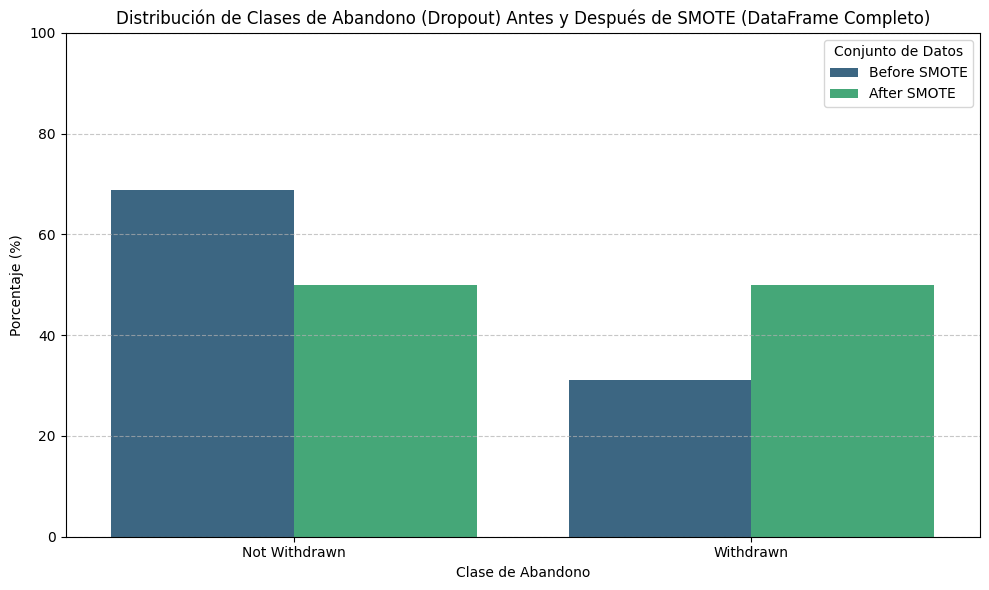

--- Visualización de balanceo de clases completada para el DataFrame completo. ---


In [13]:
print("--- Visualizando el balanceo de clases antes y después de SMOTE para el DataFrame completo ---")

# Obtener las distribuciones de clases antes (usando y_test como proxy) y después de SMOTE del DataFrame completo
# `processed_data_full` contiene los datos procesados del DataFrame completo
original_distribution = processed_data_full['y_test'].value_counts(normalize=True).mul(100)
resampled_distribution = processed_data_full['y_train_resampled'].value_counts(normalize=True).mul(100)

# Crear un DataFrame para facilitar la visualización
df_plot = pd.DataFrame({
    'Before SMOTE': original_distribution,
    'After SMOTE': resampled_distribution
}).reset_index()

# Corregir el nombre de la columna para la clase de abandono
df_plot = df_plot.rename(columns={'dropout': 'Dropout Class'})

# Mapear 0 y 1 a etiquetas más descriptivas
df_plot['Dropout Class'] = df_plot['Dropout Class'].map({0: 'Not Withdrawn', 1: 'Withdrawn'})

# Reorganizar el DataFrame para seaborn.barplot
df_plot_melted = df_plot.melt(id_vars='Dropout Class', var_name='Dataset', value_name='Percentage')

plt.figure(figsize=(10, 6))
sns.barplot(x='Dropout Class', y='Percentage', hue='Dataset', data=df_plot_melted, palette='viridis')
plt.title('Distribución de Clases de Abandono (Dropout) Antes y Después de SMOTE (DataFrame Completo)')
plt.xlabel('Clase de Abandono')
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 100)
plt.legend(title='Conjunto de Datos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- Visualización de balanceo de clases completada para el DataFrame completo. ---")

# **9. Entrenamiento y evaluación de modelos (Logistic Regression, RandomForest y Gradient Boosting)**

Procesamiento de datos

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore') # Ignorar advertencias de convergencia o de otro tipo

# Diccionario para almacenar los resultados de los modelos
model_results_full = {}

print("--- Entrenando y evaluando modelos de clasificación para el DataFrame completo ---")

# Obtener los datos procesados del DataFrame completo
X_train_resampled = processed_data_full['X_train_resampled']
y_train_resampled = processed_data_full['y_train_resampled']
X_test_original = processed_data_full['X_test']
y_test = processed_data_full['y_test']
preprocessor = processed_data_full['preprocessor']

# Transformar X_test usando el mismo preprocesador ajustado en X_train
X_test_transformed = preprocessor.transform(X_test_original)

--- Entrenando y evaluando modelos de clasificación para el DataFrame completo ---


Configuración y entrenamiento de modelos

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, fbeta_score
import warnings
warnings.filterwarnings('ignore') # Ignorar advertencias de convergencia o de otro tipo

models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Loop a través de los modelos y entrenar/evaluar
for model_name, model in models.items():
    print(f"  Entrenando {model_name}...")
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_transformed)

    # Para modelos que no tienen predict_proba (como LinearSVC sin probability=True), se podría usar decision_function
    # Sin embargo, con SVC(kernel='linear', probability=True), predict_proba estará disponible.
    y_proba = model.predict_proba(X_test_transformed)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2) # Calculate F2-Score
    roc_auc = roc_auc_score(y_test, y_proba)

    from sklearn.metrics import balanced_accuracy_score, average_precision_score
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_proba)
    print(f"   Exactitud Balanceada: {bal_acc:.4f} | PR-AUC: {pr_auc:.4f}")

    model_results_full[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'f2_score': f2, # Add F2-Score to results
        'roc_auc_score': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"    {model_name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, F2-Score: {f2:.4f}, ROC AUC: {roc_auc:.4f}")

print("\n--- Entrenamiento y evaluación de modelos completado para el DataFrame completo. ---")

  Entrenando Logistic Regression...
   Exactitud Balanceada: 0.7216 | PR-AUC: 0.7022
    Logistic Regression - Accuracy: 0.7291, Precision: 0.5513, Recall: 0.7019, F1-Score: 0.6175, F2-Score: 0.6655, ROC AUC: 0.7939
  Entrenando Random Forest...
   Exactitud Balanceada: 0.7514 | PR-AUC: 0.7409
    Random Forest - Accuracy: 0.8119, Precision: 0.7523, Recall: 0.5909, F1-Score: 0.6619, F2-Score: 0.6174, ROC AUC: 0.8198
  Entrenando Gradient Boosting...
   Exactitud Balanceada: 0.7485 | PR-AUC: 0.7512
    Gradient Boosting - Accuracy: 0.8116, Precision: 0.7578, Recall: 0.5810, F1-Score: 0.6578, F2-Score: 0.6095, ROC AUC: 0.8242

--- Entrenamiento y evaluación de modelos completado para el DataFrame completo. ---


# **9.1 Métricas de rendimiento**

In [16]:
print("--- Resumen de Resultados de Modelos para el DataFrame completo ---")

# Crear un DataFrame para almacenar todos los resultados y facilitar la visualización
all_results_df = pd.DataFrame()

# Como model_results_full es un diccionario con resultados de un solo conjunto de datos (no por ventana temporal),
# ajustamos el bucle para iterar directamente sobre él.
for model_name, metrics in model_results_full.items():
    result_row = {
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1_score'],
        'F2-Score': metrics['f2_score'],
        'ROC AUC': metrics['roc_auc_score']
    }
    all_results_df = pd.concat([all_results_df, pd.DataFrame([result_row])], ignore_index=True)
    print(f"  {model_name}:")
    print(f"    Accuracy: {metrics['accuracy']:.4f}")
    print(f"    Precision: {metrics['precision']:.4f}")
    print(f"    Recall: {metrics['recall']:.4f}")
    print(f"    F1-Score: {metrics['f1_score']:.4f}")
    print(f"    F2-Score: {metrics['f2_score']:.4f}") # Print F2-Score
    print(f"    ROC AUC: {metrics['roc_auc_score']:.4f}")

print("\n--- Tabla Resumen Completa (DataFrame completo) ---")
# Mostrar el DataFrame completo ordenado por Recall, incluyendo F2-Score
print(all_results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'F2-Score', 'ROC AUC']].sort_values(by=['Recall'], ascending=False).to_markdown(index=False))

print("\nDe los resultados, podemos analizar el rendimiento de cada modelo en el DataFrame completo.")

--- Resumen de Resultados de Modelos para el DataFrame completo ---
  Logistic Regression:
    Accuracy: 0.7291
    Precision: 0.5513
    Recall: 0.7019
    F1-Score: 0.6175
    F2-Score: 0.6655
    ROC AUC: 0.7939
  Random Forest:
    Accuracy: 0.8119
    Precision: 0.7523
    Recall: 0.5909
    F1-Score: 0.6619
    F2-Score: 0.6174
    ROC AUC: 0.8198
  Gradient Boosting:
    Accuracy: 0.8116
    Precision: 0.7578
    Recall: 0.5810
    F1-Score: 0.6578
    F2-Score: 0.6095
    ROC AUC: 0.8242

--- Tabla Resumen Completa (DataFrame completo) ---
| Model               |   Accuracy |   Precision |   Recall |   F1-Score |   F2-Score |   ROC AUC |
|:--------------------|-----------:|------------:|---------:|-----------:|-----------:|----------:|
| Logistic Regression |   0.729068 |    0.551312 | 0.701866 |   0.617545 |   0.665518 |  0.793868 |
| Random Forest       |   0.811878 |    0.752345 | 0.590864 |   0.661898 |   0.617366 |  0.819802 |
| Gradient Boosting   |   0.811572 |    0.7578

**9.2 Comparación métricas entre modelos con y sin SMOTE**

Para comparar los resultados, primero mostraremos las métricas de los modelos entrenados con SMOTE (DataFrame completo) y luego las de los modelos entrenados sin SMOTE.

In [17]:
print("--- Métricas de rendimiento de modelos CON SMOTE (DataFrame completo) ---")
print(all_results_df.sort_values(by=['F2-Score'], ascending=False).to_markdown(index=False))

print("\n--- Métricas de rendimiento de modelos SIN SMOTE ---")
print(all_results_no_smote_df.sort_values(by=['F2-Score'], ascending=False).to_markdown(index=False))

--- Métricas de rendimiento de modelos CON SMOTE (DataFrame completo) ---
| Model               |   Accuracy |   Precision |   Recall |   F1-Score |   F2-Score |   ROC AUC |
|:--------------------|-----------:|------------:|---------:|-----------:|-----------:|----------:|
| Logistic Regression |   0.729068 |    0.551312 | 0.701866 |   0.617545 |   0.665518 |  0.793868 |
| Random Forest       |   0.811878 |    0.752345 | 0.590864 |   0.661898 |   0.617366 |  0.819802 |
| Gradient Boosting   |   0.811572 |    0.757848 | 0.581041 |   0.65777  |   0.60948  |  0.824226 |

--- Métricas de rendimiento de modelos SIN SMOTE ---
| Model                            |   Accuracy |   Precision |   Recall |   F1-Score |   F2-Score |   ROC AUC |
|:---------------------------------|-----------:|------------:|---------:|-----------:|-----------:|----------:|
| Logistic Regression (No SMOTE)   |   0.724476 |    0.544765 | 0.705305 |   0.614726 |   0.666048 |  0.794215 |
| Random Forest (No SMOTE)       

Ahora, combinemos ambos DataFrames para una comparación más sencilla y directa.

In [18]:
print("--- Comparación de Métricas de Modelos (CON vs. SIN SMOTE) ---")

# Añadir una columna para indicar si SMOTE fue usado
all_results_df['SMOTE_Applied'] = 'Yes'
all_results_no_smote_df['SMOTE_Applied'] = 'No'

# Unir ambos DataFrames
comparison_df = pd.concat([all_results_df, all_results_no_smote_df], ignore_index=True)

# Reordenar columnas para mejor visualización y ordenar por métrica y tipo de modelo
comparison_df = comparison_df[['Model', 'SMOTE_Applied', 'Accuracy', 'Precision', 'Recall', 'F2-Score', 'F1-Score', 'ROC AUC']]
comparison_df['Model_Base'] = comparison_df['Model'].apply(lambda x: x.replace(' (No SMOTE)', ''))
comparison_df = comparison_df.sort_values(by=['F2-Score'], ascending=False).drop(columns=['Model_Base'])

print(comparison_df.to_markdown(index=False))

print("\nEsta tabla muestra claramente el impacto de SMOTE en las métricas de cada modelo.")

--- Comparación de Métricas de Modelos (CON vs. SIN SMOTE) ---
| Model                            | SMOTE_Applied   |   Accuracy |   Precision |   Recall |   F2-Score |   F1-Score |   ROC AUC |
|:---------------------------------|:----------------|-----------:|------------:|---------:|-----------:|-----------:|----------:|
| Logistic Regression (No SMOTE)   | No              |   0.724476 |    0.544765 | 0.705305 |   0.666048 |   0.614726 |  0.794215 |
| Logistic Regression              | Yes             |   0.729068 |    0.551312 | 0.701866 |   0.665518 |   0.617545 |  0.793868 |
| Random Forest                    | Yes             |   0.811878 |    0.752345 | 0.590864 |   0.617366 |   0.661898 |  0.819802 |
| Gradient Boosting                | Yes             |   0.811572 |    0.757848 | 0.581041 |   0.60948  |   0.65777  |  0.824226 |
| Random Forest (No SMOTE)         | No              |   0.812184 |    0.805745 | 0.523576 |   0.563008 |   0.634713 |  0.823688 |
| Gradient Boosting 

### 9.3. Visualización del ROC AUC

--- Generando gráfica comparativa de ROC AUC ---


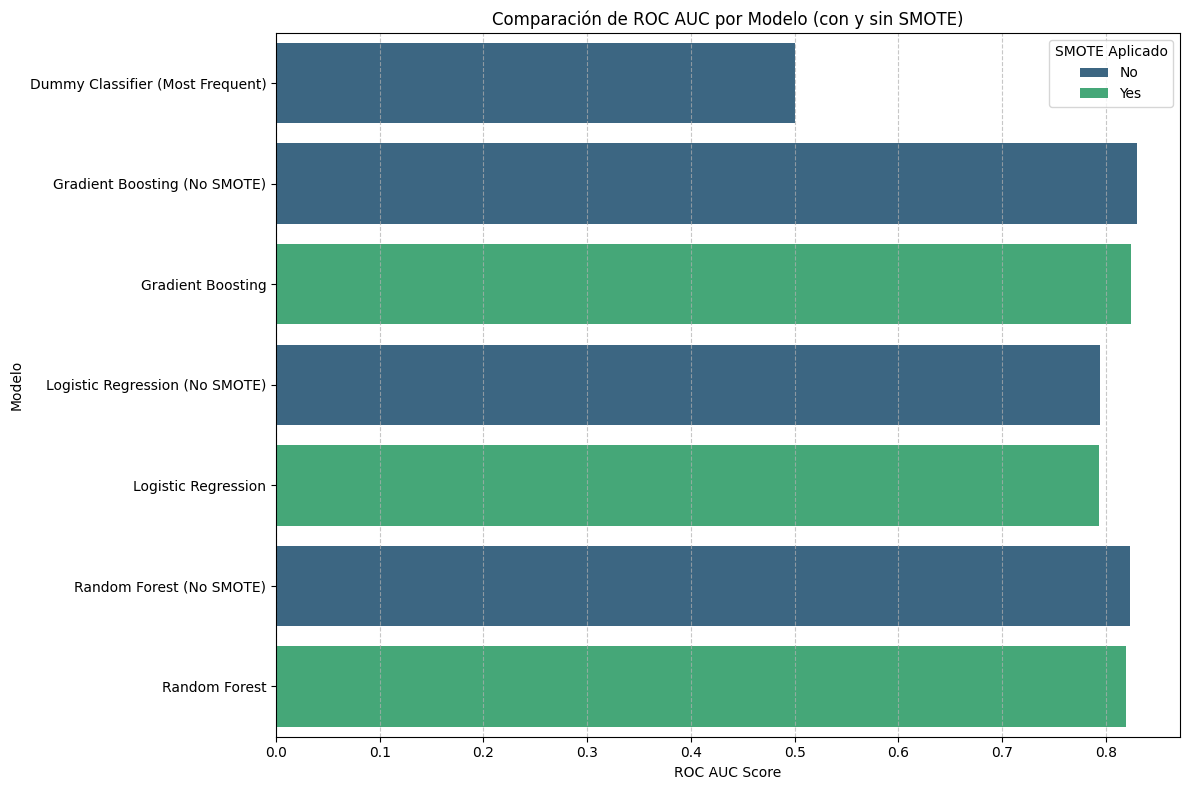

--- Gráfica de comparación de ROC AUC generada. ---


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Generando gráfica comparativa de ROC AUC ---")

# Recrear la columna 'Model_Base' para el ordenamiento dentro de esta celda
comparison_df['Model_Base'] = comparison_df['Model'].apply(lambda x: x.replace(' (No SMOTE)', ''))

plt.figure(figsize=(12, 8))
sns.barplot(x='ROC AUC', y='Model', hue='SMOTE_Applied', data=comparison_df.sort_values(by=['Model_Base', 'ROC AUC'], ascending=[True, False]), palette='viridis')
plt.title('Comparación de ROC AUC por Modelo (con y sin SMOTE)')
plt.xlabel('ROC AUC Score')
plt.ylabel('Modelo')
plt.legend(title='SMOTE Aplicado')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Eliminar la columna temporal 'Model_Base' si no se necesita más
comparison_df.drop(columns=['Model_Base'], inplace=True)

print("--- Gráfica de comparación de ROC AUC generada. ---")

### 9.4. Visualización de Métricas de Rendimiento (Comparación detallada)

--- Generando gráficas comparativas para Accuracy, Precision, Recall y F1-Score ---


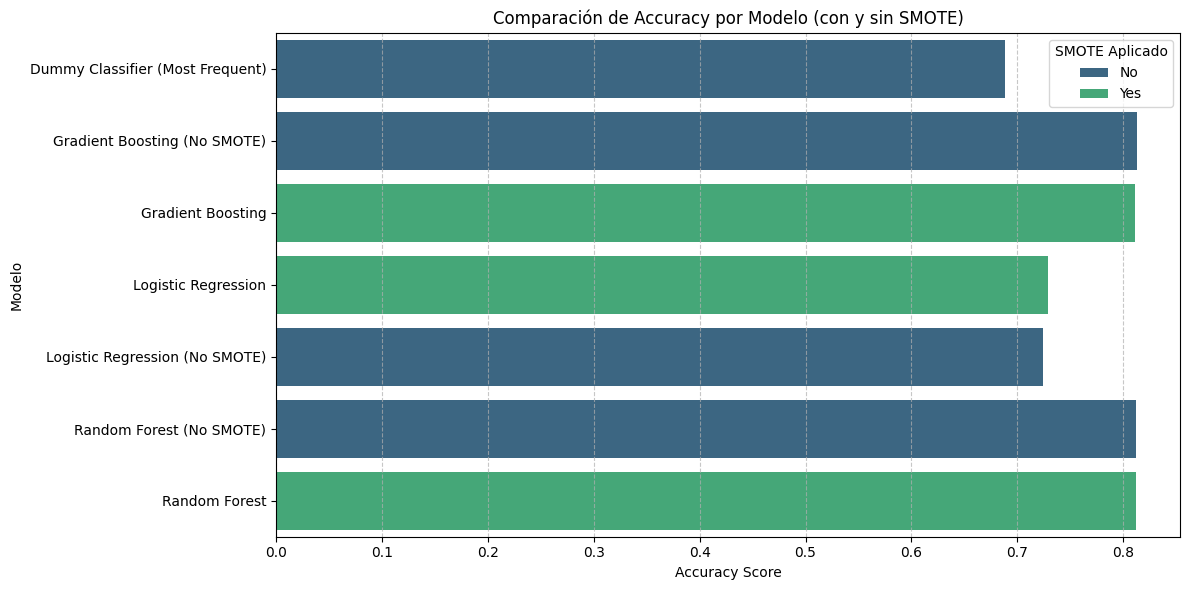

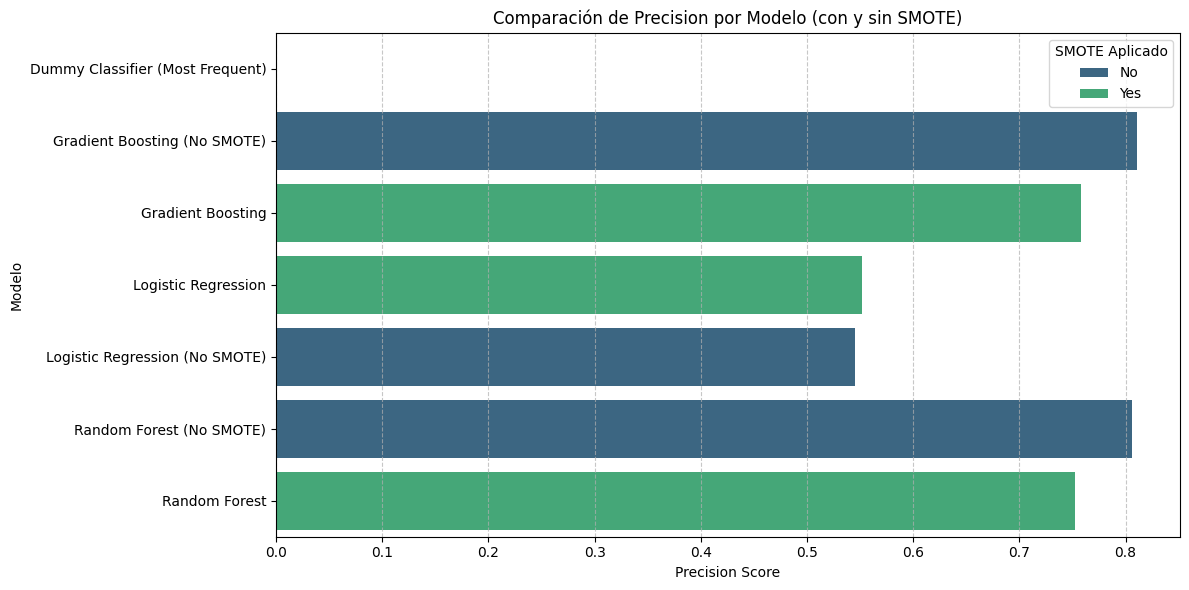

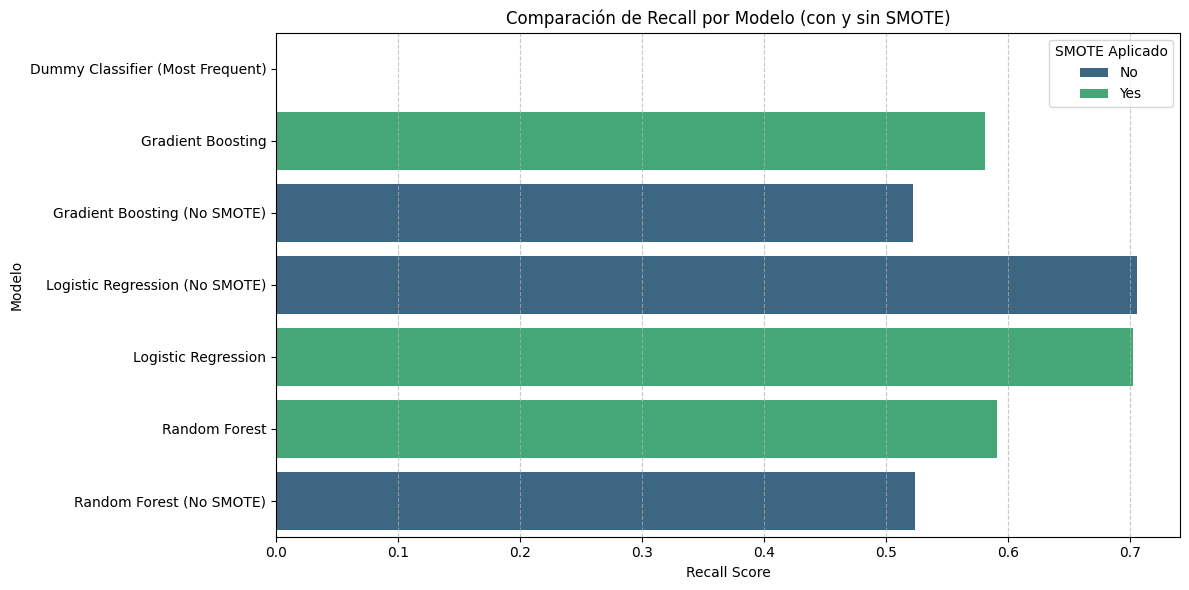

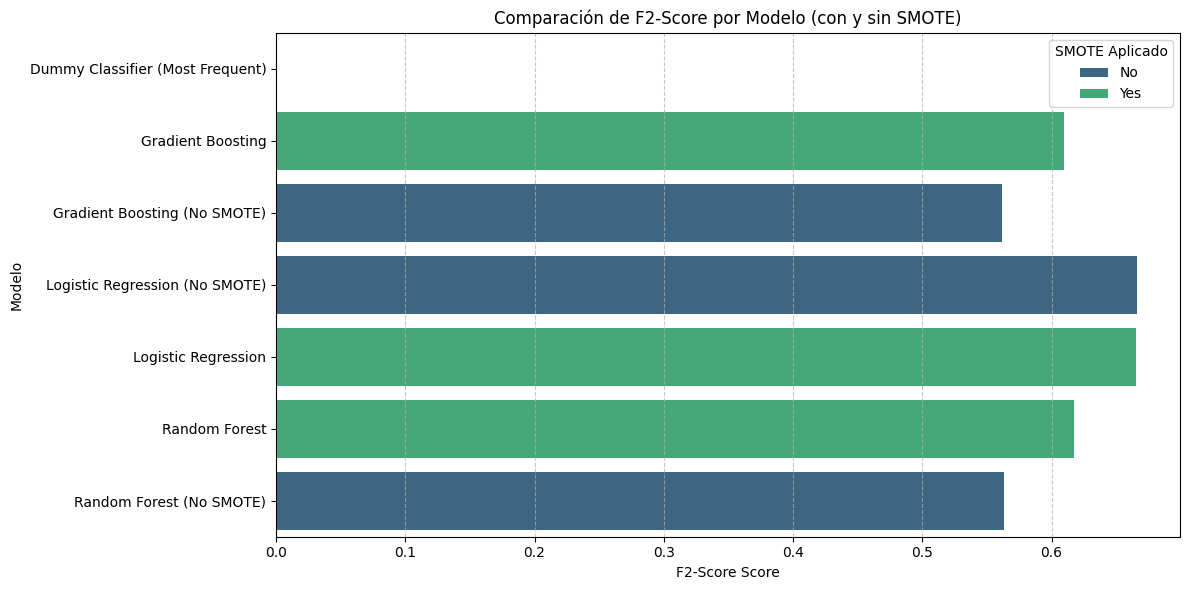

--- Gráficas de comparación de métricas generadas. ---


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Generando gráficas comparativas para Accuracy, Precision, Recall y F1-Score ---")

# Asegurarse de que comparison_df está disponible y tiene la columna 'Model_Base'
# Recrear la columna 'Model_Base' si se eliminó en celdas anteriores
if 'Model_Base' not in comparison_df.columns:
    comparison_df['Model_Base'] = comparison_df['Model'].apply(lambda x: x.replace(' (No SMOTE)', ''))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F2-Score']

for metric in metrics_to_plot:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=metric,
        y='Model',
        hue='SMOTE_Applied',
        data=comparison_df.sort_values(by=['Model_Base', metric], ascending=[True, False]),
        palette='viridis'
    )
    plt.title(f'Comparación de {metric} por Modelo (con y sin SMOTE)')
    plt.xlabel(f'{metric} Score')
    plt.ylabel('Modelo')
    plt.legend(title='SMOTE Aplicado')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Eliminar la columna temporal 'Model_Base' si ya no es necesaria
if 'Model_Base' in comparison_df.columns:
    comparison_df.drop(columns=['Model_Base'], inplace=True)

print("--- Gráficas de comparación de métricas generadas. ---")

### 9.5. Diferencia Porcentual en Métricas de Rendimiento (Con SMOTE vs. Sin SMOTE)

In [21]:
print("--- Calculando la diferencia porcentual en las métricas de rendimiento ---")

# Asegurarse de que comparison_df esté disponible y tenga la columna 'Model_Base'
if 'Model_Base' not in comparison_df.columns:
    comparison_df['Model_Base'] = comparison_df['Model'].apply(lambda x: x.replace(' (No SMOTE)', ''))

metrics_to_analyze = ['Accuracy', 'Precision', 'Recall', 'F2-Score', 'F1-Score', 'ROC AUC']
difference_results = []

for model_base in comparison_df['Model_Base'].unique():
    df_subset = comparison_df[comparison_df['Model_Base'] == model_base]

    # Extraer métricas para 'Con SMOTE' y 'Sin SMOTE'
    smote_row = df_subset[df_subset['SMOTE_Applied'] == 'Yes']
    no_smote_row = df_subset[df_subset['SMOTE_Applied'] == 'No']

    if not smote_row.empty and not no_smote_row.empty:
        smote_metrics = smote_row[metrics_to_analyze].iloc[0]
        no_smote_metrics = no_smote_row[metrics_to_analyze].iloc[0]

        diff_row = {'Model_Base': model_base}
        for metric in metrics_to_analyze:
            val_smote = smote_metrics[metric]
            val_no_smote = no_smote_metrics[metric]

            if val_no_smote != 0:
                percentage_diff = ((val_smote - val_no_smote) / val_no_smote) * 100
            else:
                percentage_diff = np.nan # Evitar división por cero
            diff_row[f'Diff_{metric}_%'] = percentage_diff
        difference_results.append(diff_row)

percentage_difference_df = pd.DataFrame(difference_results)

print("\n--- Tabla de Diferencias Porcentuales --- ")
print(percentage_difference_df.to_markdown(index=False))

print("\n--- Cálculo de diferencias porcentuales completado. ---")

--- Calculando la diferencia porcentual en las métricas de rendimiento ---

--- Tabla de Diferencias Porcentuales --- 
| Model_Base          |   Diff_Accuracy_% |   Diff_Precision_% |   Diff_Recall_% |   Diff_F2-Score_% |   Diff_F1-Score_% |   Diff_ROC AUC_% |
|:--------------------|------------------:|-------------------:|----------------:|------------------:|------------------:|-----------------:|
| Logistic Regression |         0.633847  |            1.20179 |       -0.487465 |        -0.0796269 |          0.458635 |       -0.0437171 |
| Random Forest       |        -0.0376932 |           -6.62732 |       12.8518   |         9.65491   |          4.28312  |       -0.47177   |
| Gradient Boosting   |        -0.16946   |           -6.51787 |       11.3936   |         8.51263   |          3.62051  |       -0.693034  |

--- Cálculo de diferencias porcentuales completado. ---


## 10. Entrenamiento de Modelos con Validación Cruzada (StratifiedGroupKFold)

In [51]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, fbeta_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore') # Ignorar advertencias de convergencia o de otro tipo

print("--- Configurando y ejecutando Validación Cruzada con StratifiedGroupKFold ---")

# Usar el DataFrame completo 'all_student_data_preprocessed'
current_df_cv = all_student_data_preprocessed.copy()

# 1. Separar características (X), variable objetivo (y) y grupos (id_student)
# 'code_module', 'code_presentation' y 'region' (si no se usa en pipeline) también deben ser eliminados de X.
X_cv = current_df_cv.drop(columns=['dropout', 'code_module', 'code_presentation', 'id_student', 'region'])
y_cv = current_df_cv['dropout']
groups_cv = current_df_cv['id_student']

# Identificar columnas numéricas, categóricas y booleanas para el ColumnTransformer
# Estas deben ser las mismas que se usarán en el preprocesamiento con SMOTE
numerical_cols_cv = X_cv.select_dtypes(include=np.number).columns.tolist()
categorical_cols_cv = X_cv.select_dtypes(include='object').columns.tolist()
boolean_cols_cv = X_cv.select_dtypes(include='bool').columns.tolist()

# Definir el preprocesador
preprocessor_cv = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_cv),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_cv)
    ],
    remainder='passthrough' # Mantiene las columnas booleanas ya creadas
)

# Definir los modelos a evaluar
models_cv = {
    'Logistic Regression CV': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Random Forest CV': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting CV': GradientBoostingClassifier(random_state=42)
}

# Configurar StratifiedGroupKFold
n_splits = 5 # Número de folds
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Diccionario para almacenar los resultados de cada fold y cada modelo
cv_results = {name: {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'f2_score': [], 'roc_auc': []} for name in models_cv.keys()}

print(f"  Iniciando validación cruzada con {n_splits} folds...")

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_cv, y_cv, groups_cv)):
    print(f"\n    --- Fold {fold + 1}/{n_splits} ---")

    X_train_fold, X_test_fold = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
    y_train_fold, y_test_fold = y_cv.iloc[train_idx], y_cv.iloc[test_idx]

    # Crear un pipeline que incluye preprocesamiento y SMOTE para este fold
    # Es CRÍTICO que SMOTE se aplique SÓLO a los datos de entrenamiento de cada fold
    pipeline_with_smote = ImbPipeline([
        ('preprocessor', preprocessor_cv),
        ('smote', SMOTE(random_state=42))
    ])

    # Ajustar y transformar los datos de entrenamiento, solo transformar los datos de prueba
    X_train_processed, y_train_processed = pipeline_with_smote.fit_resample(X_train_fold, y_train_fold)

    # Transformar X_test_fold usando el preprocesador ajustado en el pipeline (sin SMOTE para el test set)
    # Obtenemos el preprocesador del pipeline ajustado
    preprocessor_fitted = pipeline_with_smote.named_steps['preprocessor']
    X_test_processed = preprocessor_fitted.transform(X_test_fold)

    print(f"      Dimensiones X_train_processed: {X_train_processed.shape}")
    print(f"      Distribución y_train_processed:\n{y_train_processed.value_counts(normalize=True)}")

    for model_name, model in models_cv.items():
        print(f"      Entrenando {model_name} para el Fold {fold + 1}...")
        model.fit(X_train_processed, y_train_processed)
        y_pred_fold = model.predict(X_test_processed)
        y_proba_fold = model.predict_proba(X_test_processed)[:, 1]

        cv_results[model_name]['accuracy'].append(accuracy_score(y_test_fold, y_pred_fold))
        cv_results[model_name]['precision'].append(precision_score(y_test_fold, y_pred_fold))
        cv_results[model_name]['recall'].append(recall_score(y_test_fold, y_pred_fold))
        cv_results[model_name]['f1_score'].append(f1_score(y_test_fold, y_pred_fold))
        cv_results[model_name]['f2_score'].append(fbeta_score(y_test_fold, y_pred_fold, beta=2)) # Calculate F2-Score
        cv_results[model_name]['roc_auc'].append(roc_auc_score(y_test_fold, y_proba_fold))

        # --- PEGAR AQUÍ ---
        from sklearn.metrics import balanced_accuracy_score, average_precision_score
        bal_acc_cv = balanced_accuracy_score(y_test_fold, y_pred_fold)
        pr_auc_cv = average_precision_score(y_test_fold, y_proba_fold)
        print(f"    [MÉTRICAS EXTRA] Exactitud Balanceada: {bal_acc_cv:.4f} | PR-AUC: {pr_auc_cv:.4f}")
        # ------------------

print("\n--- Validación Cruzada completada. ---")

# --- Resumen de Resultados de Validación Cruzada ---
print("\n--- Resumen de Resultados Promedio de Validación Cruzada ---")
final_cv_summary = pd.DataFrame()

for model_name, metrics in cv_results.items():
    avg_accuracy = np.mean(metrics['accuracy'])
    std_accuracy = np.std(metrics['accuracy'])
    avg_precision = np.mean(metrics['precision'])
    std_precision = np.std(metrics['precision'])
    avg_recall = np.mean(metrics['recall'])
    std_recall = np.std(metrics['recall'])
    avg_f1 = np.mean(metrics['f1_score'])
    std_f1 = np.std(metrics['f1_score'])
    avg_f2 = np.mean(metrics['f2_score'])
    std_f2 = np.std(metrics['f2_score'])
    avg_roc_auc = np.mean(metrics['roc_auc'])
    std_roc_auc = np.std(metrics['roc_auc'])

    result_row = {
        'Model': model_name,
        'Avg Accuracy': avg_accuracy,
        'Std Accuracy': std_accuracy,
        'Avg Precision': avg_precision,
        'Std Precision': std_precision,
        'Avg Recall': avg_recall,
        'Std Recall': std_recall,
        'Avg F1-Score': avg_f1,
        'Std F1-Score': std_f1,
        'Avg F2-Score': avg_f2,
        'Std F2-Score': std_f2,
        'Avg ROC AUC': avg_roc_auc,
        'Std ROC AUC': std_roc_auc
    }
    final_cv_summary = pd.concat([final_cv_summary, pd.DataFrame([result_row])], ignore_index=True)

# Ordenar por 'Avg F2-Score' como solicitado
print(final_cv_summary.sort_values(by='Avg F2-Score', ascending=False).to_markdown(index=False))

print("\nEsta tabla muestra las métricas promedio de cada modelo a través de los folds de validación cruzada.")

--- Configurando y ejecutando Validación Cruzada con StratifiedGroupKFold ---
  Iniciando validación cruzada con 5 folds...

    --- Fold 1/5 ---
      Dimensiones X_train_processed: (35884, 40)
      Distribución y_train_processed:
dropout
0    0.5
1    0.5
Name: proportion, dtype: float64
      Entrenando Logistic Regression CV para el Fold 1...
    [MÉTRICAS EXTRA] Exactitud Balanceada: 0.7118 | PR-AUC: 0.6927
      Entrenando Random Forest CV para el Fold 1...
    [MÉTRICAS EXTRA] Exactitud Balanceada: 0.7381 | PR-AUC: 0.7237
      Entrenando Gradient Boosting CV para el Fold 1...
    [MÉTRICAS EXTRA] Exactitud Balanceada: 0.7331 | PR-AUC: 0.7300

    --- Fold 2/5 ---
      Dimensiones X_train_processed: (35774, 40)
      Distribución y_train_processed:
dropout
0    0.5
1    0.5
Name: proportion, dtype: float64
      Entrenando Logistic Regression CV para el Fold 2...
    [MÉTRICAS EXTRA] Exactitud Balanceada: 0.7129 | PR-AUC: 0.6834
      Entrenando Random Forest CV para el Fold 2

### 10.1. Visualización de Resultados de Validación Cruzada

--- Generando gráficas comparativas de las métricas de CV ---


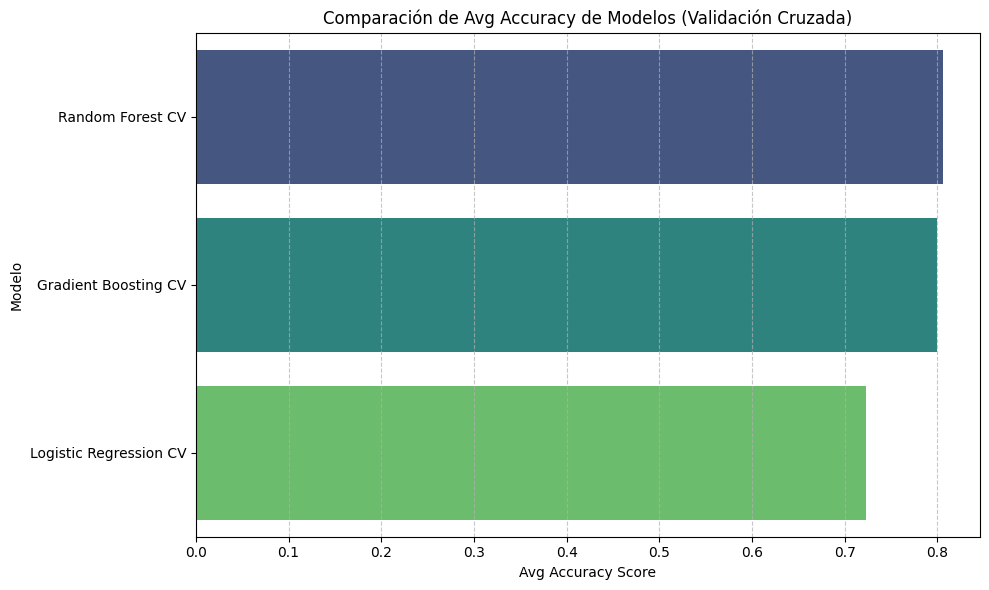

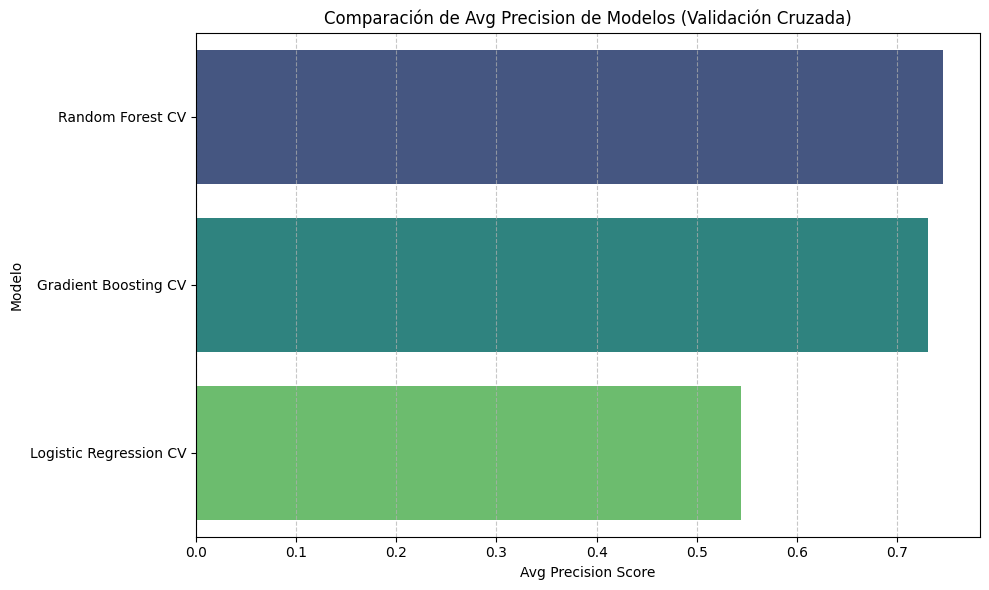

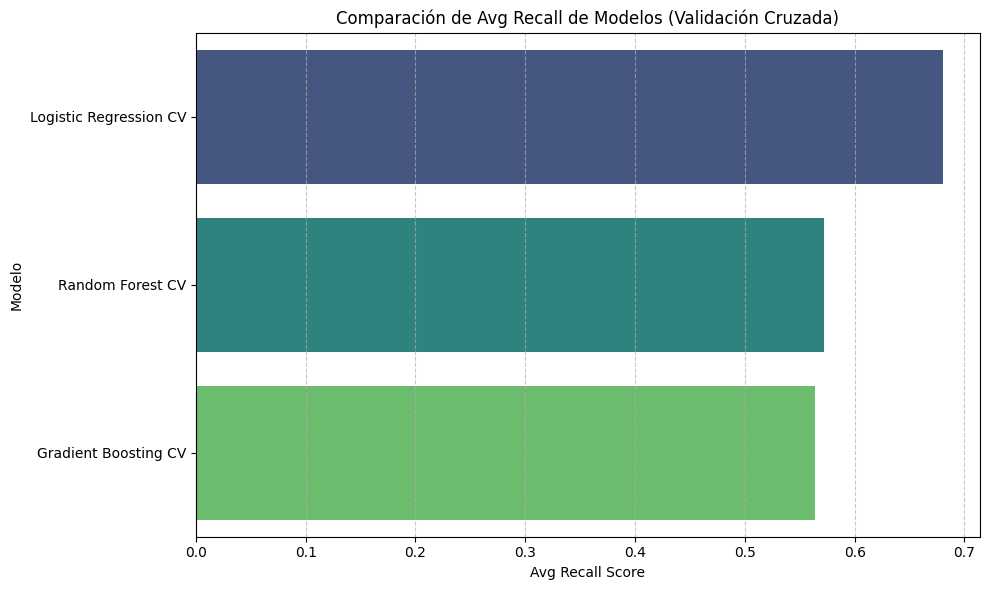

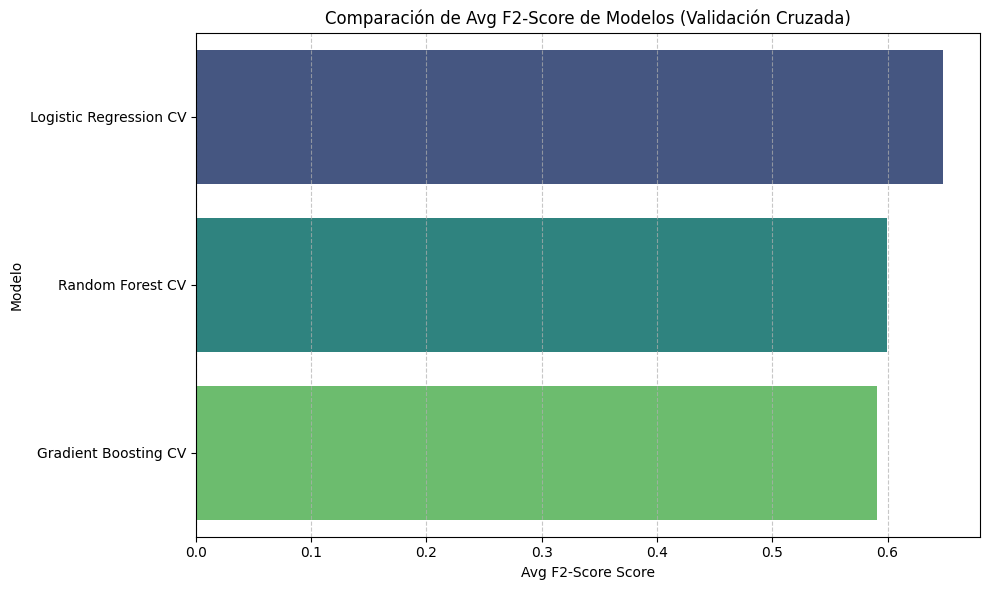

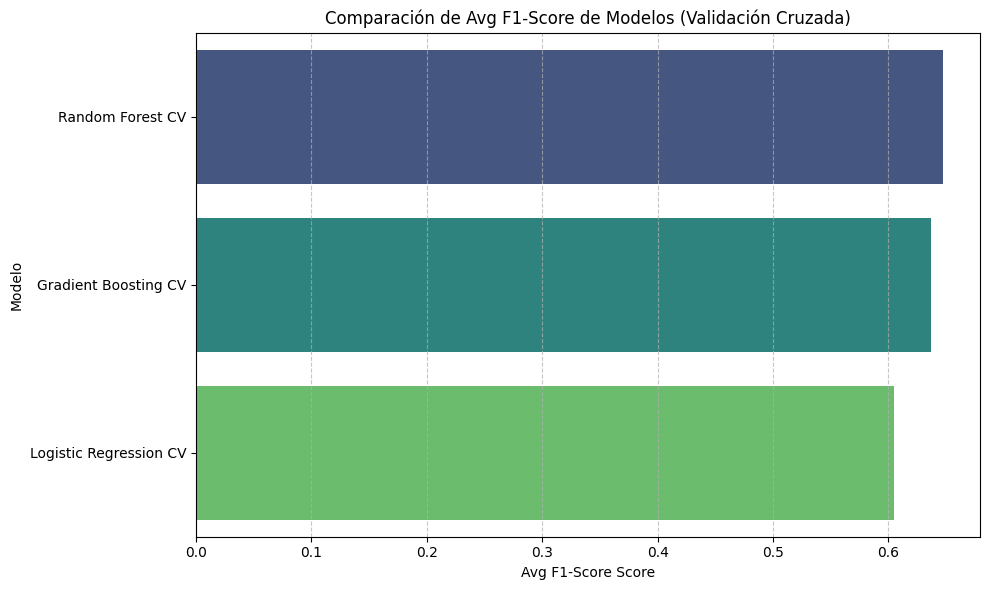

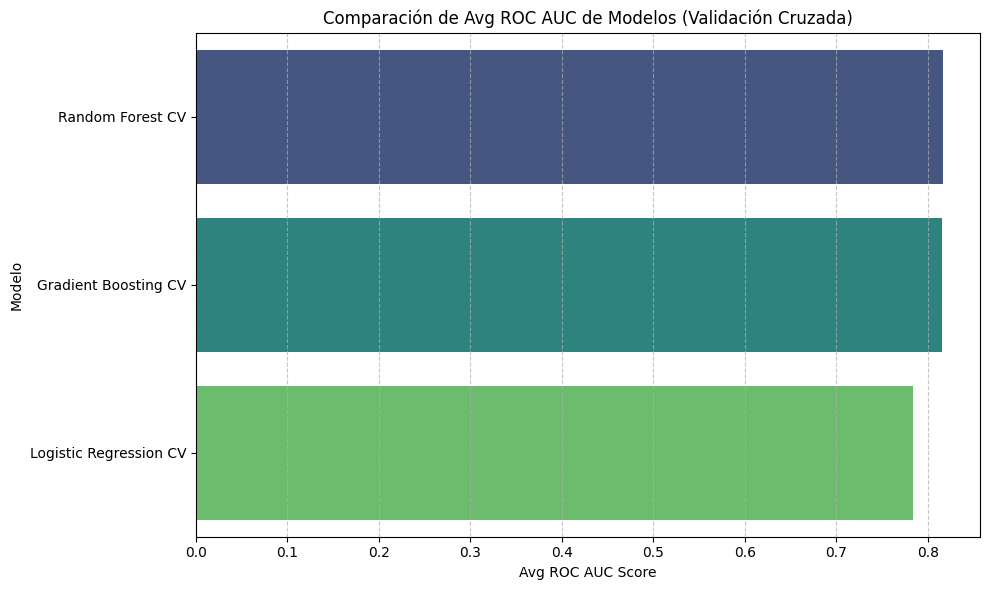

--- Gráficas de comparación de métricas de CV generadas. ---


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Generando gráficas comparativas de las métricas de CV ---")

metrics_to_plot_cv = ['Avg Accuracy', 'Avg Precision', 'Avg Recall', 'Avg F2-Score', 'Avg F1-Score', 'Avg ROC AUC']

for metric_cv in metrics_to_plot_cv:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=metric_cv,
        y='Model',
        data=final_cv_summary.sort_values(by=metric_cv, ascending=False),
        palette='viridis'
    )
    plt.title(f'Comparación de {metric_cv} de Modelos (Validación Cruzada)')
    plt.xlabel(f'{metric_cv} Score')
    plt.ylabel('Modelo')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

print("--- Gráficas de comparación de métricas de CV generadas. ---")

### 10.2. Comparación de Métricas: Validación Cruzada vs. Modelos SIN y CON SMOTE

--- Preparando datos para la comparación de métricas --- 
--- Generando gráficas comparativas --- 


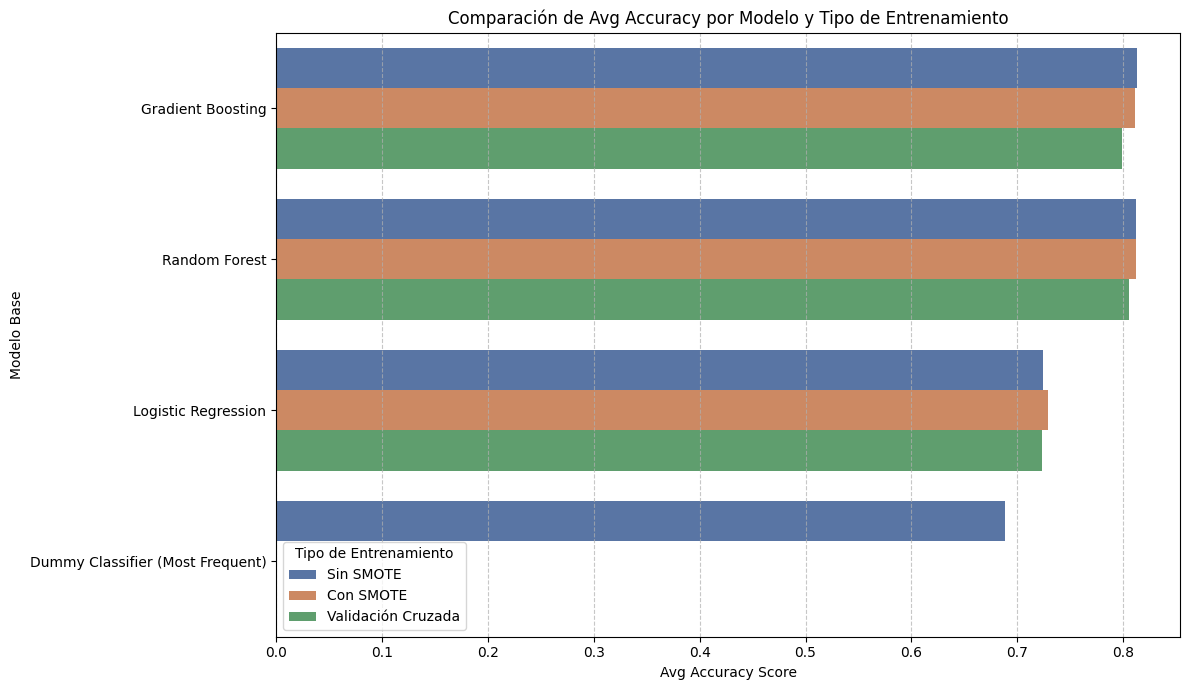

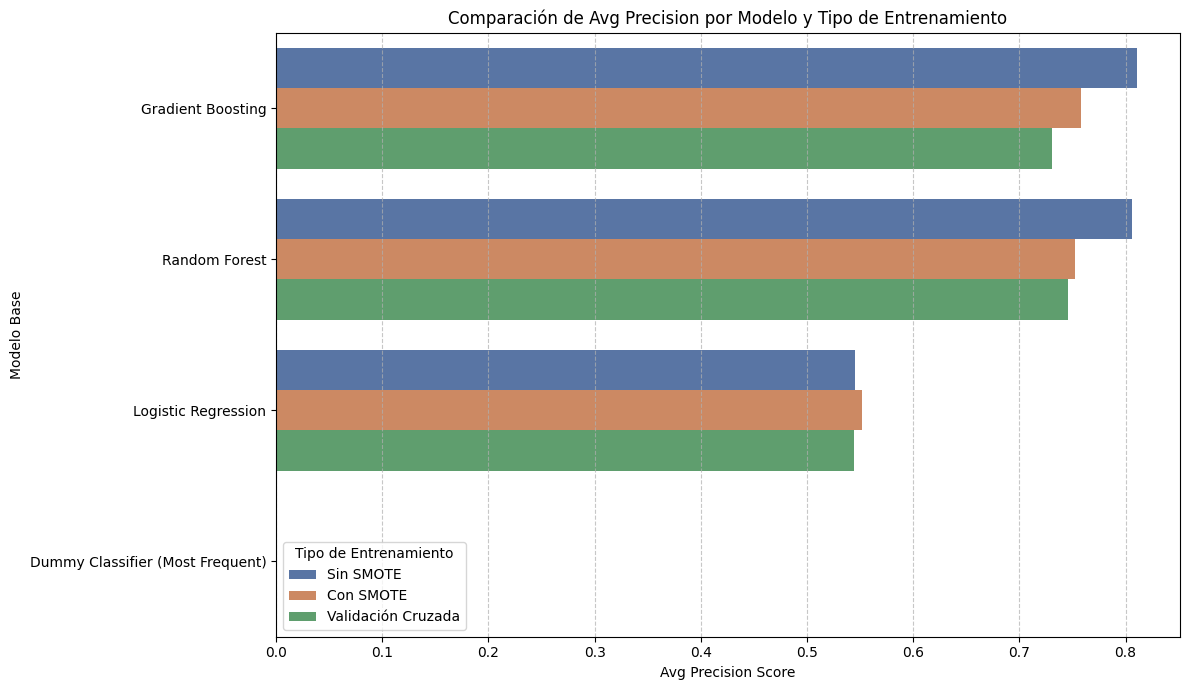

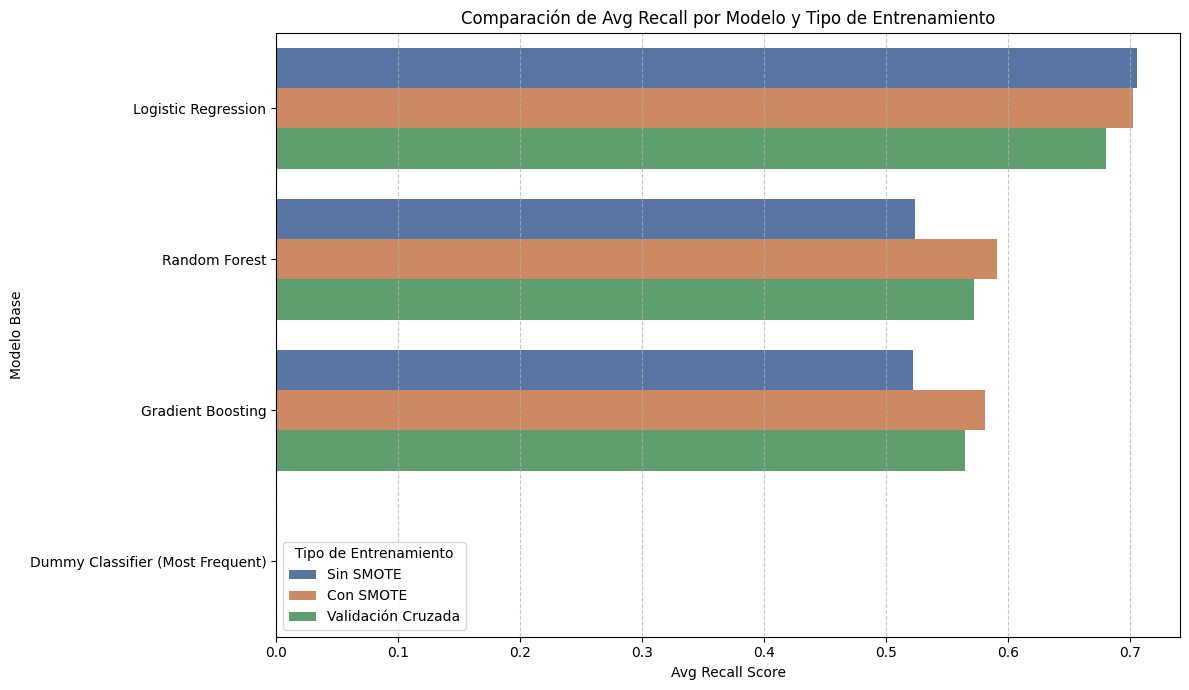

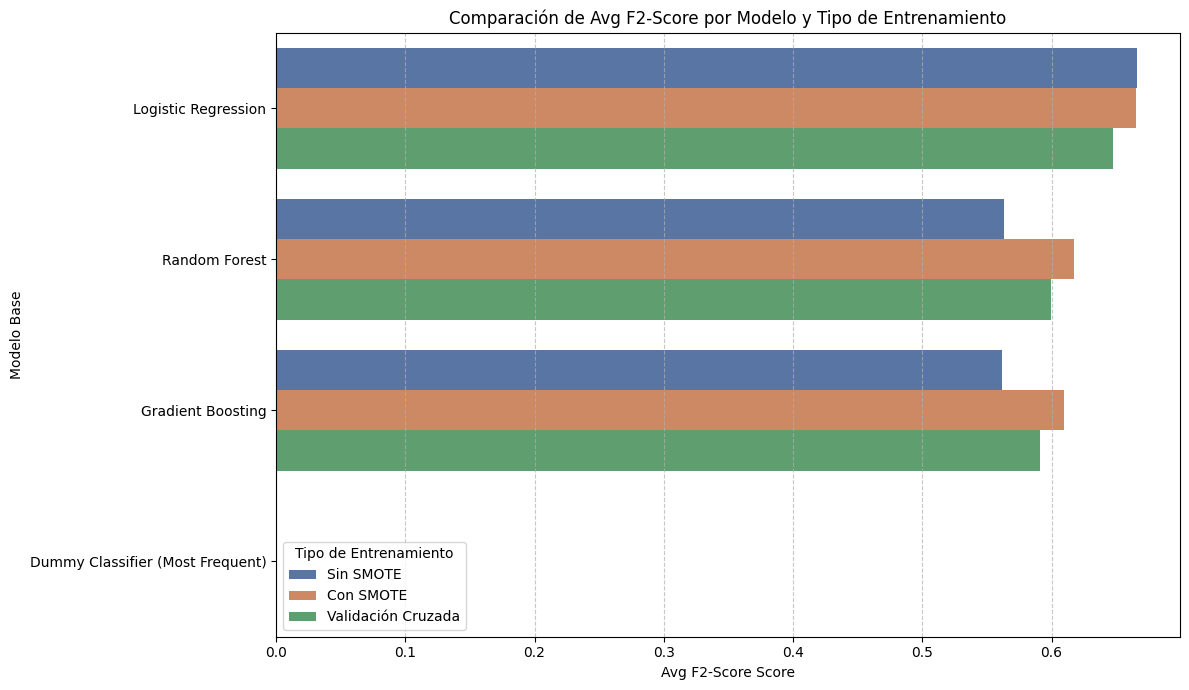

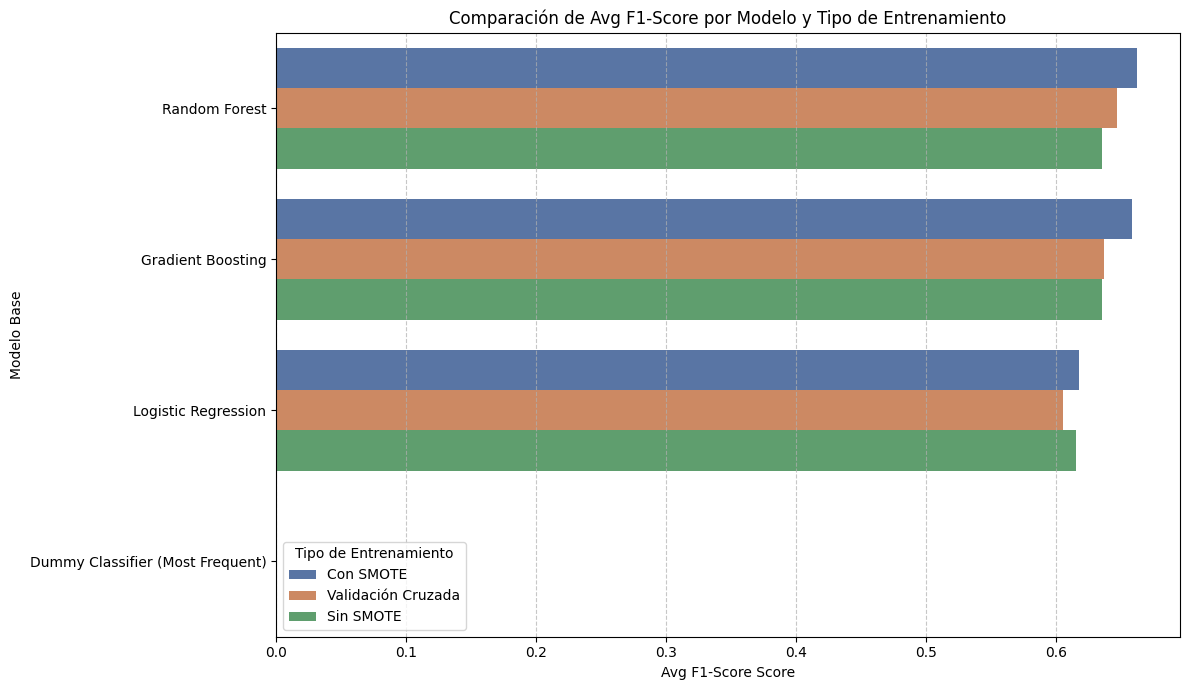

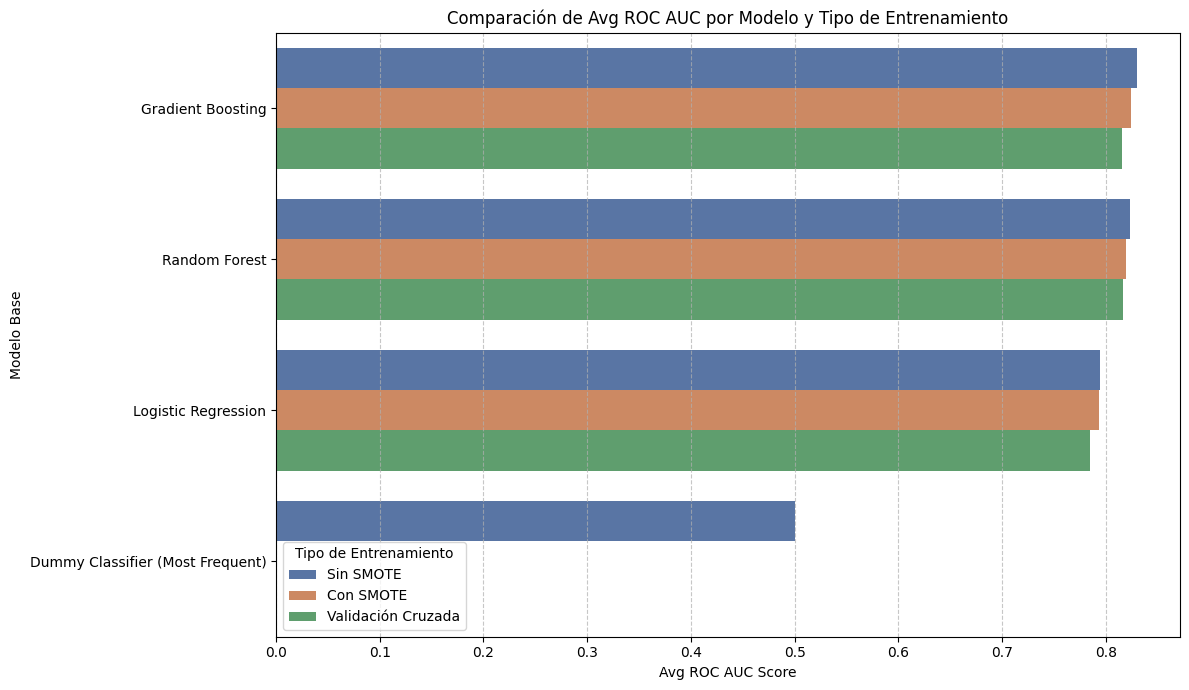

--- Gráficas de comparación de métricas generadas. --- 


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Preparando datos para la comparación de métricas --- ")

# Preparar el DataFrame de resultados con SMOTE (all_results_df)
comparison_smote = all_results_df.copy()
comparison_smote['Model_Type'] = 'Con SMOTE'
comparison_smote.rename(columns={
    'Accuracy': 'Avg Accuracy',
    'Precision': 'Avg Precision',
    'Recall': 'Avg Recall',
    'F2-Score': 'Avg F2-Score',
    'F1-Score': 'Avg F1-Score',
    'ROC AUC': 'Avg ROC AUC'
}, inplace=True)

# Preparar el DataFrame de resultados sin SMOTE (all_results_no_smote_df)
comparison_no_smote = all_results_no_smote_df.copy()
comparison_no_smote['Model_Type'] = 'Sin SMOTE'
comparison_no_smote.rename(columns={
    'Accuracy': 'Avg Accuracy',
    'Precision': 'Avg Precision',
    'Recall': 'Avg Recall',
    'F2-Score': 'Avg F2-Score',
    'F1-Score': 'Avg F1-Score',
    'ROC AUC': 'Avg ROC AUC'
}, inplace=True)

# Preparar el DataFrame de resultados de CV (final_cv_summary)
comparison_cv = final_cv_summary.copy()
comparison_cv['Model_Type'] = 'Validación Cruzada'

# Unir todos los DataFrames para la comparación
full_comparison_df = pd.concat([comparison_smote, comparison_no_smote, comparison_cv], ignore_index=True)

# Normalizar los nombres de los modelos para agrupar
full_comparison_df['Base_Model'] = full_comparison_df['Model'].apply(lambda x:
    x.replace(' (No SMOTE)', '').replace(' CV', '').strip()
)

print("--- Generando gráficas comparativas --- ")

metrics_to_compare = ['Avg Accuracy', 'Avg Precision', 'Avg Recall', 'Avg F2-Score', 'Avg F1-Score', 'Avg ROC AUC']

for metric in metrics_to_compare:
    plt.figure(figsize=(12, 7))
    sns.barplot(
        x=metric,
        y='Base_Model',
        hue='Model_Type',
        data=full_comparison_df.sort_values(by=[metric], ascending=False),
        palette='deep'
    )
    plt.title(f'Comparación de {metric} por Modelo y Tipo de Entrenamiento')
    plt.xlabel(f'{metric} Score')
    plt.ylabel('Modelo Base')
    plt.legend(title='Tipo de Entrenamiento')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

print("--- Gráficas de comparación de métricas generadas. --- ")

### 10.3. Selección del Mejor Modelo y Análisis de Importancia de Características

In [25]:
print("--- Re-evaluando el mejor modelo usando múltiples métricas ---")

# Asignar pesos a las métricas para un sistema de alerta temprana (priorizando Recall)
# Recall es crucial para minimizar falsos negativos (no identificar a un estudiante en riesgo).
# F2-Score es un buen balance entre Precision y Recall.
# ROC AUC da una medida general de la capacidad de discriminación del modelo.
weights = {
    'Recall': 0.4,
    'F2-Score': 0.3,
    'ROC AUC': 0.3
}

# Calcular una puntuación compuesta para cada modelo
all_results_df['Composite_Score'] = (
    all_results_df['Recall'] * weights['Recall'] +
    all_results_df['F2-Score'] * weights['F2-Score'] +
    all_results_df['ROC AUC'] * weights['ROC AUC']
)

# Identificar el modelo con la puntuación compuesta más alta
best_model_row = all_results_df.sort_values(by='Composite_Score', ascending=False).iloc[0]
best_model_name = best_model_row['Model']

print(f"El mejor modelo, basado en una puntuación compuesta (Recall ponderado), es: {best_model_name}")
print("Métricas del modelo seleccionado:")
print(f"  Accuracy: {best_model_row['Accuracy']:.4f}")
print(f"  Precision: {best_model_row['Precision']:.4f}")
print(f"  Recall: {best_model_row['Recall']:.4f}")
print(f"  F2-Score: {best_model_row['F2-Score']:.4f}")
print(f"  F1-Score: {best_model_row['F1-Score']:.4f}")
print(f"  ROC AUC: {best_model_row['ROC AUC']:.4f}")
print(f"  Composite Score: {best_model_row['Composite_Score']:.4f}")

print(
    "Para fines de visualización de importancia de características, "
    f"usaremos el '{best_model_name}' ya que tuvo el mejor desempeño global y es un modelo interpretable."
)


--- Re-evaluando el mejor modelo usando múltiples métricas ---
El mejor modelo, basado en una puntuación compuesta (Recall ponderado), es: Logistic Regression
Métricas del modelo seleccionado:
  Accuracy: 0.7291
  Precision: 0.5513
  Recall: 0.7019
  F2-Score: 0.6655
  F1-Score: 0.6175
  ROC AUC: 0.7939
  Composite Score: 0.7186
Para fines de visualización de importancia de características, usaremos el 'Logistic Regression' ya que tuvo el mejor desempeño global y es un modelo interpretable.


--- Visualizando la importancia de las características del modelo de Regresión Logística ---


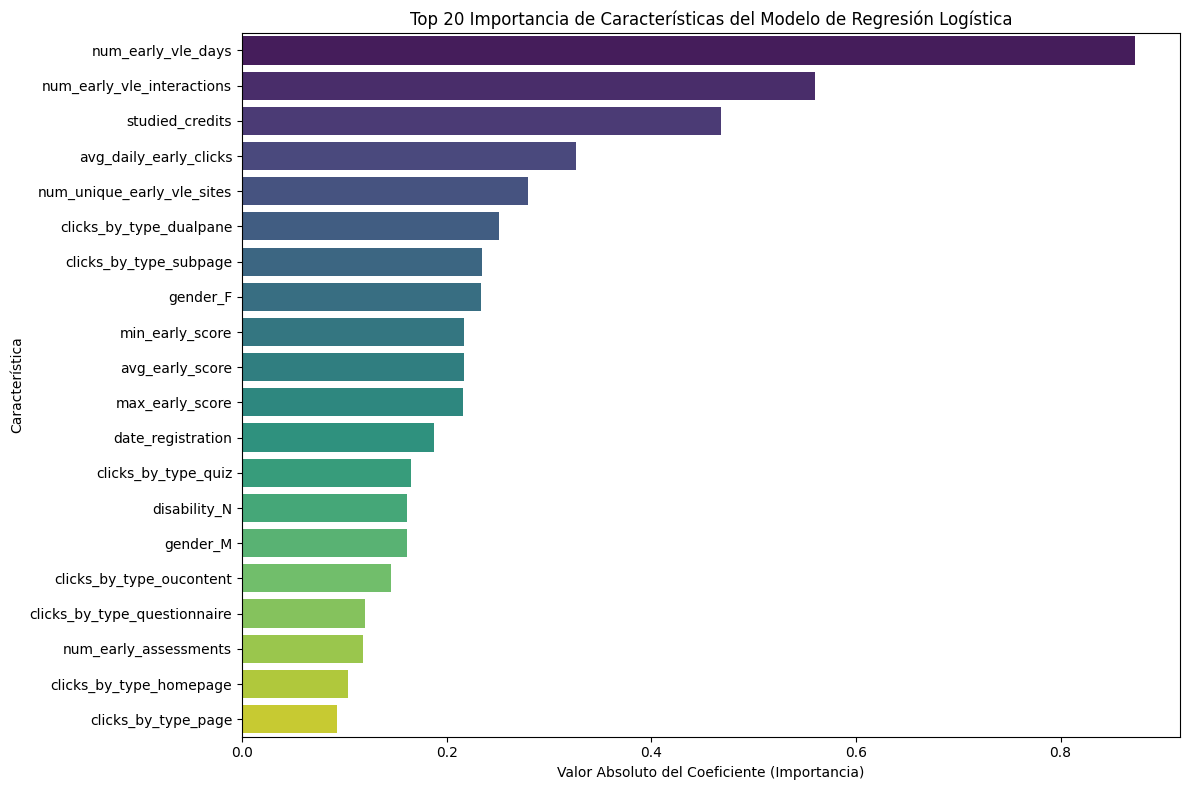

--- Visualización de la importancia de las características completada para Logistic Regression. ---


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Visualizando la importancia de las características del modelo de Regresión Logística ---")

# Obtener el modelo de Regresión Logística seleccionado
best_lr_model = model_results_full['Logistic Regression']['model']

# Obtener el objeto ColumnTransformer usado para el preprocesamiento
preprocessor = processed_data_full['preprocessor']

# Obtener los nombres de las características después del preprocesamiento
transformed_feature_names = preprocessor.get_feature_names_out()

# Limpiar los nombres de las características para una mejor visualización
cleaned_feature_names = []
for name in transformed_feature_names:
    # Eliminar prefijos del ColumnTransformer (e.g., 'num__', 'cat__', 'remainder__')
    if name.startswith('num__'):
        cleaned_feature_names.append(name.replace('num__', ''))
    elif name.startswith('cat__'):
        cleaned_feature_names.append(name.replace('cat__', ''))
    elif name.startswith('remainder__'):
        cleaned_feature_names.append(name.replace('remainder__', ''))
    else:
        cleaned_feature_names.append(name)

# Para Regresión Logística, los coeficientes representan la importancia de las características
# Usamos el valor absoluto para comparar la magnitud de la influencia.
feature_importance_df_lr = pd.DataFrame({
    'Feature': cleaned_feature_names,
    'Importance': np.abs(best_lr_model.coef_[0])
})

# Ordenar por importancia y seleccionar las top N características
feature_importance_df_lr = feature_importance_df_lr.sort_values(by='Importance', ascending=False)

# Visualizar las top 20 características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_lr.head(20), palette='viridis')
plt.title('Top 20 Importancia de Características del Modelo de Regresión Logística')
plt.xlabel('Valor Absoluto del Coeficiente (Importancia)')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

print("--- Visualización de la importancia de las características completada para Logistic Regression. ---")

# **11. Ajustes de hiperparámetros**

In [27]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("--- Ajuste de hiperparámetros para Random Forest (GridSearchCV y RandomizedSearchCV) ---")

# Obtener los datos de entrenamiento originales (no resampleados) y el preprocesador
X_train = processed_data_full['X_train_original'] # Use original X_train
y_train = processed_data_full['y_train_original'] # Use original y_train
preprocessor = processed_data_full['preprocessor'] # Get the preprocessor

# Inicializar el modelo Random Forest con el class_weight
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Crear un pipeline con preprocesamiento, SMOTE y el modelo Random Forest
pipeline_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('randomforestclassifier', rf_model) # Name the RandomForest step
])

# --- 1. Ajuste con GridSearchCV ---
print("\nIniciando ajuste con GridSearchCV...")
param_grid_grid = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [10, 20, None],
    'randomforestclassifier__min_samples_split': [2, 5],
    'randomforestclassifier__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=pipeline_rf, # Use the pipeline here
    param_grid=param_grid_grid,
    scoring='roc_auc',
    cv=3, # Usar 3-fold cross-validation
    n_jobs=-1, # Usar todos los núcleos disponibles
    verbose=1
)

grid_search.fit(X_train, y_train) # Fit with original X_train, y_train

print("GridSearchCV completado.")
print(f"Mejores parámetros con GridSearchCV: {grid_search.best_params_}")
print(f"Mejor ROC AUC con GridSearchCV: {grid_search.best_score_:.4f}")

# --- 2. Ajuste con RandomizedSearchCV ---
print("\nIniciando ajuste con RandomizedSearchCV...")
param_grid_random = {
    'randomforestclassifier__n_estimators': [100, 200, 300, 400],
    'randomforestclassifier__max_features': ['sqrt', 'log2', 0.8, 1.0],
    'randomforestclassifier__max_depth': [10, 20, 30, None],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_rf, # Use the pipeline here
    param_distributions=param_grid_random,
    n_iter=20, # Aumentado el número de combinaciones a probar
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train) # Fit with original X_train, y_train

print("RandomizedSearchCV completado.")
print(f"Mejores parámetros con RandomizedSearchCV: {random_search.best_params_}")
print(f"Mejor ROC AUC con RandomizedSearchCV: {random_search.best_score_:.4f}")

print("\n--- Ajustes de hiperparámetros finalizados. ---")

--- Ajuste de hiperparámetros para Random Forest (GridSearchCV y RandomizedSearchCV) ---

Iniciando ajuste con GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
GridSearchCV completado.
Mejores parámetros con GridSearchCV: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 100}
Mejor ROC AUC con GridSearchCV: 0.6963

Iniciando ajuste con RandomizedSearchCV...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
RandomizedSearchCV completado.
Mejores parámetros con RandomizedSearchCV: {'randomforestclassifier__n_estimators': 400, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__max_features': 'log2', 'randomforestclassifier__max_depth': 10}
Mejor ROC AUC con RandomizedSearchCV: 0.6977

--- Ajustes de hiperparámetros finalizados. ---


# **11.1 Reconfiguración, entrenamiento y evaluación del modelo Random Forest**

In [28]:
from sklearn.metrics import balanced_accuracy_score, average_precision_score

print("--- Reconfigurando y evaluando el mejor modelo Random Forest ---\n")

# Obtener los mejores parámetros de RandomizedSearchCV
best_rf_params = random_search.best_params_

# Eliminar el prefijo 'randomforestclassifier__' de los nombres de los parámetros
# ya que se va a crear una instancia directa de RandomForestClassifier
cleaned_rf_params = {
    key.replace('randomforestclassifier__', ''): value
    for key, value in best_rf_params.items()
}

# Crear una nueva instancia de RandomForestClassifier con los mejores parámetros
best_rf_model_tuned = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    **cleaned_rf_params # Usar los parámetros con los nombres corregidos
)

print("  Entrenando el modelo Random Forest reconfigurado...")
# Para entrenar el modelo reconfigurado, necesitamos usar el pipeline completo
# ya que el preprocesamiento y SMOTE deben aplicarse consistentemente.
# Se crea un nuevo pipeline con el modelo afinado para entrenar.

pipeline_rf_tuned = ImbPipeline([
    ('preprocessor', processed_data_full['preprocessor']),
    ('smote', SMOTE(random_state=42)),
    ('randomforestclassifier', best_rf_model_tuned)
])

pipeline_rf_tuned.fit(processed_data_full['X_train_original'], processed_data_full['y_train_original'])

# Realizar predicciones en el conjunto de prueba usando el pipeline afinado
y_pred_tuned_rf = pipeline_rf_tuned.predict(processed_data_full['X_test'])
y_proba_tuned_rf = pipeline_rf_tuned.predict_proba(processed_data_full['X_test'])[:, 1]

# Evaluar el modelo reconfigurado
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)
f2_tuned_rf = fbeta_score(y_test, y_pred_tuned_rf, beta=2) # Calculate F2-Score
roc_auc_tuned_rf = roc_auc_score(y_test, y_proba_tuned_rf)

# **NUEVAS MÉTRICAS**
balanced_accuracy_tuned_rf = balanced_accuracy_score(y_test, y_pred_tuned_rf)
pr_auc_tuned_rf = average_precision_score(y_test, y_proba_tuned_rf)

print(f"  Modelo Random Forest Reconfigurado - Accuracy: {accuracy_tuned_rf:.4f}, Precision: {precision_tuned_rf:.4f}, Recall: {recall_tuned_rf:.4f}, F1-Score: {f1_tuned_rf:.4f}, F2-Score: {f2_tuned_rf:.4f}, Balanced Accuracy: {balanced_accuracy_tuned_rf:.4f}, PR-AUC: {pr_auc_tuned_rf:.4f}, ROC AUC: {roc_auc_tuned_rf:.4f}")

# Actualizar los resultados en model_results_full (o crear una nueva entrada)
model_results_full['Random Forest Tuned'] = {
    'model': pipeline_rf_tuned, # Almacenar el pipeline completo afinado
    'accuracy': accuracy_tuned_rf,
    'precision': precision_tuned_rf,
    'recall': recall_tuned_rf,
    'f1_score': f1_tuned_rf,
    'f2_score': f2_tuned_rf, # Add F2-Score to results
    'balanced_accuracy': balanced_accuracy_tuned_rf, # Add Balanced Accuracy
    'pr_auc': pr_auc_tuned_rf, # Add PR-AUC
    'roc_auc_score': roc_auc_tuned_rf,
    'y_pred': y_pred_tuned_rf,
    'y_proba': y_proba_tuned_rf
}

print("\n--- Reconfiguración y evaluación del modelo Random Forest completada. ---")

--- Reconfigurando y evaluando el mejor modelo Random Forest ---

  Entrenando el modelo Random Forest reconfigurado...
  Modelo Random Forest Reconfigurado - Accuracy: 0.8073, Precision: 0.7239, Recall: 0.6169, F1-Score: 0.6661, F2-Score: 0.6357, Balanced Accuracy: 0.7552, PR-AUC: 0.7565, ROC AUC: 0.8278

--- Reconfiguración y evaluación del modelo Random Forest completada. ---


**11.1.1 Métricas del modelo Random Forest reconfigurado**

In [29]:
from sklearn.metrics import balanced_accuracy_score, average_precision_score

print("--- Métricas del modelo Random Forest Reconfigurado ---")

# Obtener las métricas del modelo Random Forest Tuned
metrics_tuned = model_results_full['Random Forest Tuned']

print(f"  Accuracy: {metrics_tuned['accuracy']:.4f}")
print(f"  Precision: {metrics_tuned['precision']:.4f}")
print(f"  Recall: {metrics_tuned['recall']:.4f}")
print(f"  F2-Score: {metrics_tuned['f2_score']:.4f}") # Print F2-Score
print(f"  F1-Score: {metrics_tuned['f1_score']:.4f}")
print(f"  Balanced Accuracy: {metrics_tuned['balanced_accuracy']:.4f}") # Display Balanced Accuracy
print(f"  PR-AUC: {metrics_tuned['pr_auc']:.4f}") # Display PR-AUC
print(f"  ROC AUC: {metrics_tuned['roc_auc_score']:.4f}")

print("\n--- Visualización de métricas completada. ---")

--- Métricas del modelo Random Forest Reconfigurado ---
  Accuracy: 0.8073
  Precision: 0.7239
  Recall: 0.6169
  F2-Score: 0.6357
  F1-Score: 0.6661
  Balanced Accuracy: 0.7552
  PR-AUC: 0.7565
  ROC AUC: 0.8278

--- Visualización de métricas completada. ---


**11.1.2 Reporte de clasificación del modelo Random Forest reconfigurado**

In [30]:
from sklearn.metrics import classification_report

print("--- Reporte de Clasificación para el modelo Random Forest reconfigurado ---\n")

# Obtener las predicciones del modelo Logistic Regression ajustado
y_pred_tuned = model_results_full['Random Forest Tuned']['y_pred']
y_test = processed_data_full['y_test'] # Asegurarse de usar el y_test original

# Generar y mostrar el reporte de clasificación
report = classification_report(y_test, y_pred_tuned, target_names=['No Abandono', 'Abandono'])
print(report)

print("\n--- Reporte de clasificación completado. ---")

--- Reporte de Clasificación para el modelo Random Forest reconfigurado ---

              precision    recall  f1-score   support

 No Abandono       0.84      0.89      0.86      4497
    Abandono       0.72      0.62      0.67      2036

    accuracy                           0.81      6533
   macro avg       0.78      0.76      0.77      6533
weighted avg       0.80      0.81      0.80      6533


--- Reporte de clasificación completado. ---


**11.1.3 Matriz de confusión modelo Random Forest Reconfigurado**

--- Visualizando la matriz de confusión para el modelo Random Forest Reconfigurado ---


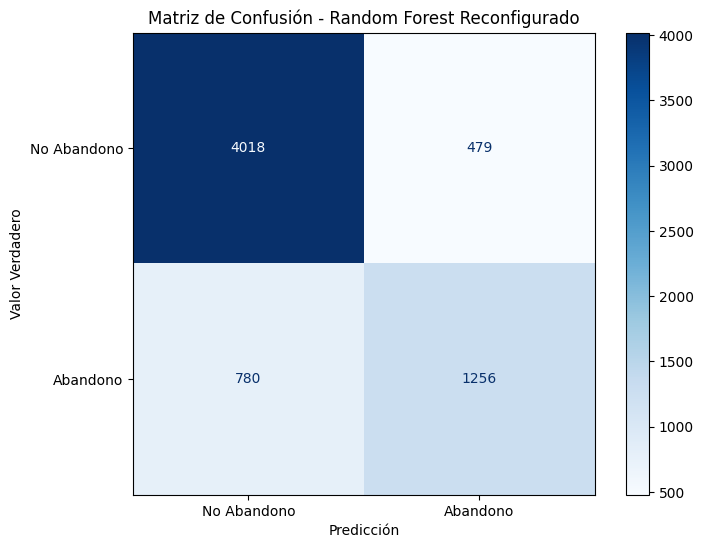

--- Visualización de la matriz de confusión completada. ---


In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- Visualizando la matriz de confusión para el modelo Random Forest Reconfigurado ---")

# Obtener las predicciones y las etiquetas verdaderas del modelo ajustado
y_pred_tuned = model_results_full['Random Forest Tuned']['y_pred']
y_test = processed_data_full['y_test'] # Asegurarse de usar el y_test original

# Crear la matriz de confusión y visualizarla
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, ax=ax, cmap='Blues', display_labels=['No Abandono', 'Abandono'])
plt.title('Matriz de Confusión - Random Forest Reconfigurado')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.grid(False)
plt.show()

print("--- Visualización de la matriz de confusión completada. ---")

# **11.1.4 Visualización curva ROC-AUC**

--- Visualizando la curva ROC-AUC del modelo Random Forest ajustado ---


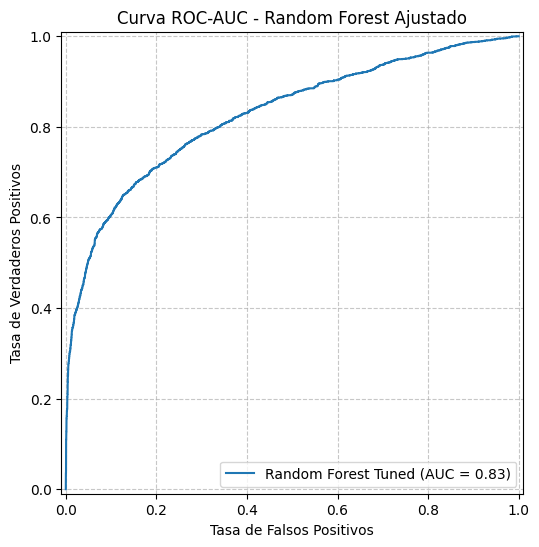

--- Visualización de la curva ROC-AUC completada. ---


In [32]:
print("--- Visualizando la curva ROC-AUC del modelo Random Forest ajustado ---")

# Obtener el modelo ajustado y sus probabilidades del diccionario de resultados
best_lr_model_tuned = model_results_full['Random Forest Tuned']['model']
y_proba_tuned = model_results_full['Random Forest Tuned']['y_proba']
y_test = processed_data_full['y_test'] # Asegurarse de usar el y_test original

plt.figure(figsize=(8, 6))
ax = plt.gca()

RocCurveDisplay.from_estimator(best_lr_model_tuned, processed_data_full['X_test'], y_test, ax=ax, name='Random Forest Tuned')
plt.title('Curva ROC-AUC - Random Forest Ajustado')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

print("--- Visualización de la curva ROC-AUC completada. ---")

# **11.1.5 Importancia de características**

--- Visualizando la importancia de las características del modelo de Random Forest Ajustado ---


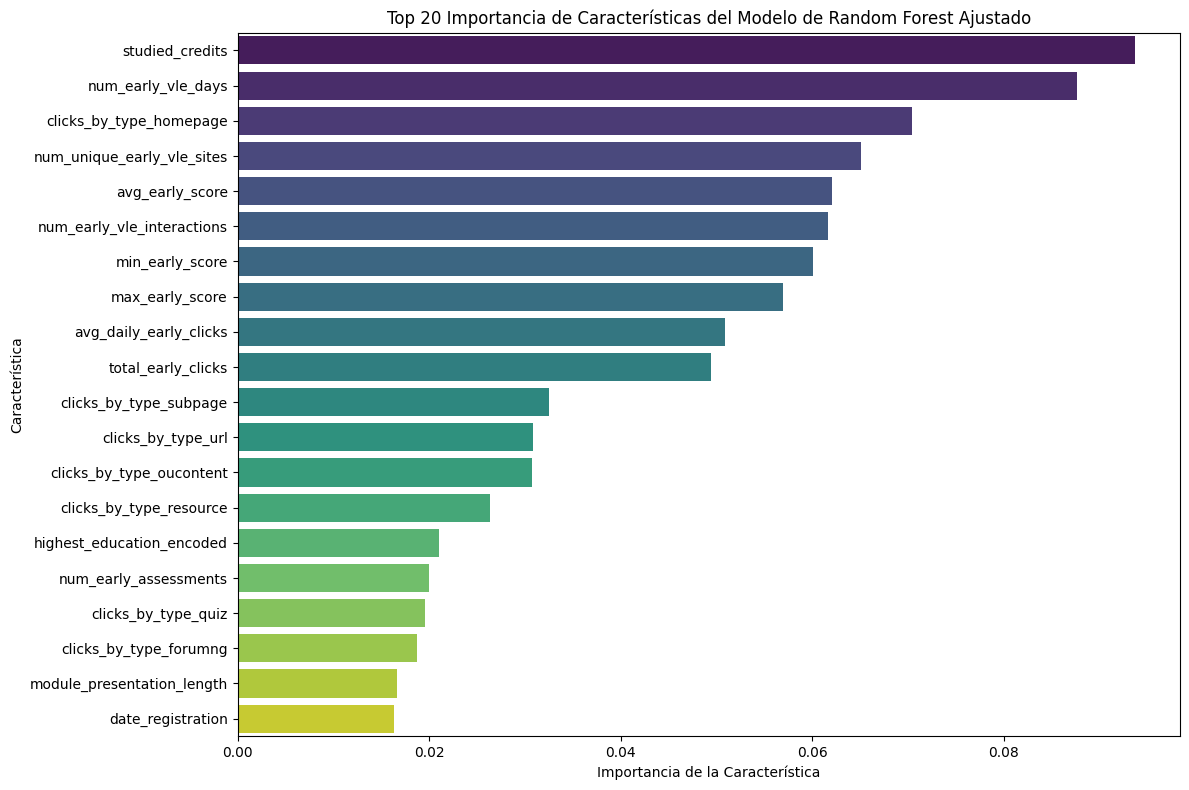

--- Visualización de la importancia de las características completada para Random Forest Ajustado. ---


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Visualizando la importancia de las características del modelo de Random Forest Ajustado ---")

# Obtener el modelo de Random Forest ajustado (tuned) seleccionado
best_rf_model = model_results_full['Random Forest Tuned']['model']

# Obtener el objeto ColumnTransformer usado para el preprocesamiento
preprocessor = processed_data_full['preprocessor']

# Obtener los nombres de las características después del preprocesamiento
transformed_feature_names = preprocessor.get_feature_names_out()

# Limpiar los nombres de las características para una mejor visualización
cleaned_feature_names = []
for name in transformed_feature_names:
    # Eliminar prefijos del ColumnTransformer (e.g., 'num__', 'cat__', 'remainder__')
    if name.startswith('num__'):
        cleaned_feature_names.append(name.replace('num__', ''))
    elif name.startswith('cat__'):
        cleaned_feature_names.append(name.replace('cat__', ''))
    elif name.startswith('remainder__'):
        cleaned_feature_names.append(name.replace('remainder__', ''))
    else:
        cleaned_feature_names.append(name)

# Para Random Forest, la importancia de las características se accede a través de 'feature_importances_'
# Acceder al Random Forest Classifier dentro del pipeline para obtener feature_importances_
feature_importance_df_rf = pd.DataFrame({
    'Feature': cleaned_feature_names,
    'Importance': best_rf_model.named_steps['randomforestclassifier'].feature_importances_
})

# Ordenar por importancia y seleccionar las top N características
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False)

# Visualizar las top 20 características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf.head(20), palette='viridis')
plt.title('Top 20 Importancia de Características del Modelo de Random Forest Ajustado')
plt.xlabel('Importancia de la Característica')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

print("--- Visualización de la importancia de las características completada para Random Forest Ajustado. ---")

# **11.1.6 Explicabilidad con SHAP**

--- Generando explicabilidad con SHAP para el modelo Random Forest ajustado ---

--- Visualizando la importancia global de las características (Summary Plot) ---


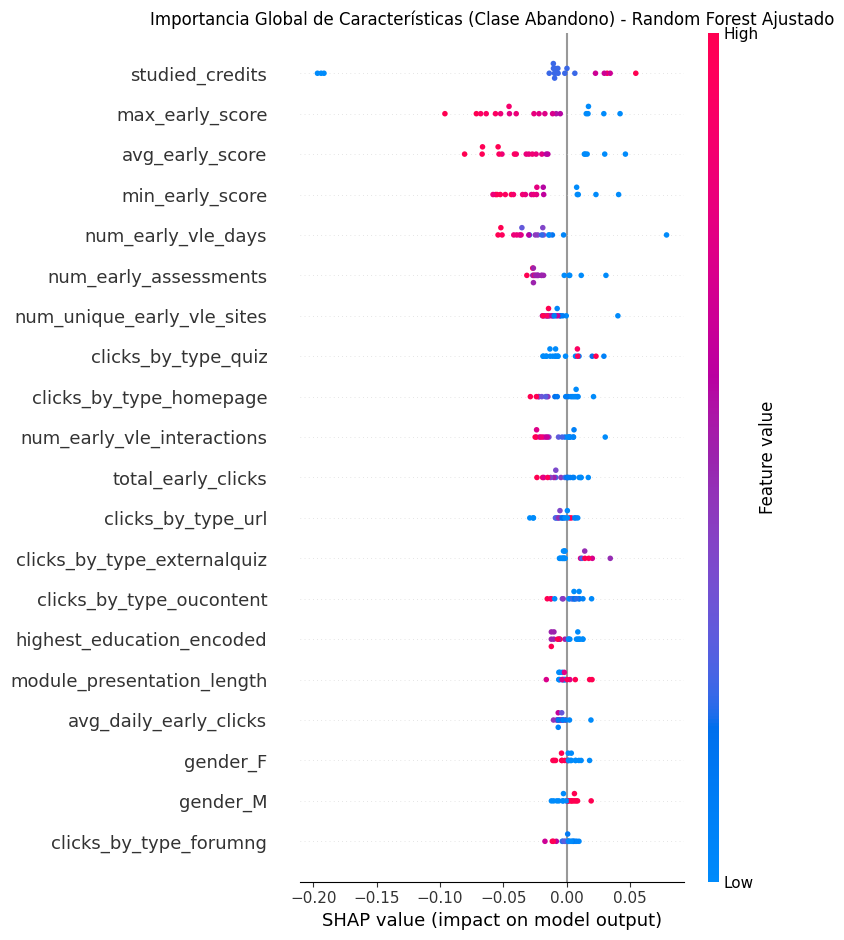


--- Visualizando la importancia de características para una instancia individual (Force Plot) ---
Explicando la instancia con índice original: 5436


<Figure size 1500x500 with 0 Axes>

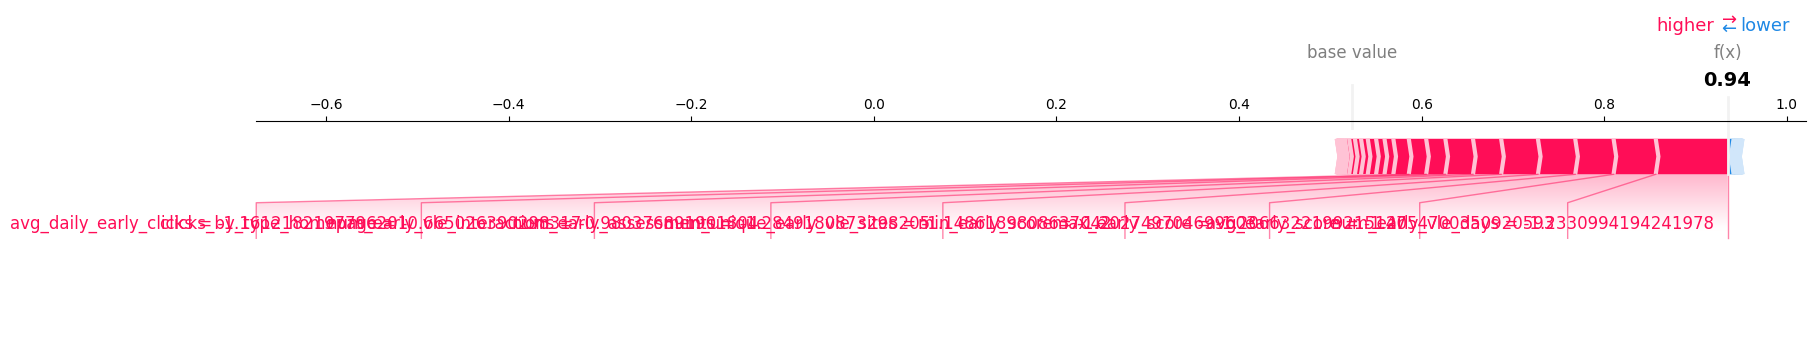

Force Plot guardado como 'force_plot_instance_5436.png'.

--- Explicabilidad con SHAP completada. ---


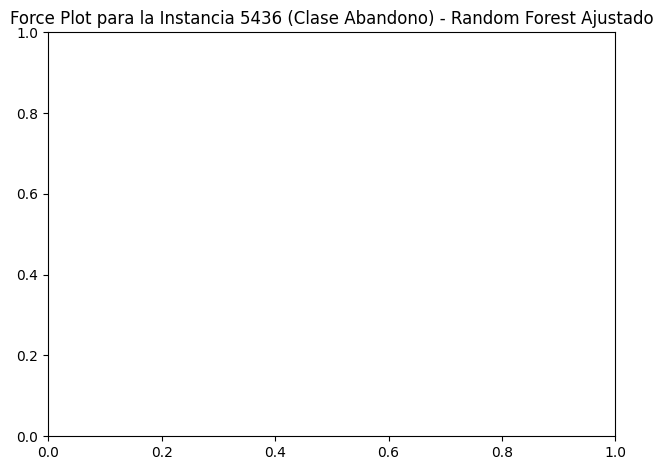

In [34]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") # Suprimir todas las advertencias en esta celda

print("--- Generando explicabilidad con SHAP para el modelo Random Forest ajustado ---")

try:
    # 1. Obtener el modelo y los datos preprocesados
    # El modelo guardado en model_results_full es una Pipeline de imblearn.
    # Necesitamos extraer el RandomForestClassifier de esa pipeline.
    best_rf_model_tuned_pipeline = model_results_full['Random Forest Tuned']['model']
    best_rf_model = best_rf_model_tuned_pipeline.named_steps['randomforestclassifier']
    preprocessor = processed_data_full['preprocessor']

    X_train_resampled_np = processed_data_full['X_train_resampled'] # Es un numpy array
    X_test_original = processed_data_full['X_test']

    # Transformar X_test usando el preprocesador (devuelve un numpy array)
    X_test_transformed_np = preprocessor.transform(X_test_original)

    # Obtener los nombres de las características después del preprocesamiento
    transformed_feature_names = preprocessor.get_feature_names_out()
    cleaned_feature_names = []
    for name in transformed_feature_names:
        if name.startswith('num__'):
            cleaned_feature_names.append(name.replace('num__', ''))
        elif name.startswith('cat__'):
            cleaned_feature_names.append(name.replace('cat__', ''))
        elif name.startswith('remainder__'):
            cleaned_feature_names.append(name.replace('remainder__', ''))
        else:
            cleaned_feature_names.append(name)

    # Convertir los arrays numpy a DataFrames con nombres de columnas para SHAP
    X_train_resampled_df = pd.DataFrame(X_train_resampled_np, columns=cleaned_feature_names)
    X_test_transformed_df = pd.DataFrame(X_test_transformed_np, columns=cleaned_feature_names)

    # Tomar una muestra de los datos de entrenamiento para el fondo del explainer
    # Esto es importante si el conjunto de entrenamiento es muy grande.
    n_background_sample = min(50, X_train_resampled_df.shape[0]) # Reducido a 50
    background_sample = X_train_resampled_df.sample(n=n_background_sample, random_state=42)

    # Tomar una muestra de los datos de prueba para calcular los valores SHAP
    # Reducimos la muestra para mitigar problemas de memoria.
    n_test_sample = min(20, X_test_transformed_df.shape[0]) # Reducido a 20 para intentar evitar truncamiento
    X_test_sample = X_test_transformed_df.sample(n=n_test_sample, random_state=42)

    # 2. Inicializar el Explainer de SHAP
    # Para Random Forest (modelo basado en árboles), se usa shap.TreeExplainer
    explainer = shap.TreeExplainer(best_rf_model, background_sample)

    # 3. Calcular los valores SHAP
    raw_shap_values = explainer.shap_values(X_test_sample)

    # Determinar qué SHAP values usar para la clase 'Abandono' (clase 1)
    # y el valor esperado para esa clase.

    # Para modelos multi-output (incluyendo clasificación binaria donde shap_values es una lista de arrays o un array 3D)
    if isinstance(raw_shap_values, list) or (isinstance(raw_shap_values, np.ndarray) and raw_shap_values.ndim == 3):
        # SHAP values para la clase positiva (clase 1)
        if isinstance(raw_shap_values, list):
            shap_values_for_plot_class1 = raw_shap_values[1]
        else: # Es un array numpy 3D
            shap_values_for_plot_class1 = raw_shap_values[:, :, 1]

        # Valor esperado para la clase positiva (clase 1)
        # explainer.expected_value es un array de valores esperados por clase
        expected_value_for_plot = explainer.expected_value[1]
    else: # Modelo de una sola salida, raw_shap_values es un array 2D (n_instances, n_features)
        shap_values_for_plot_class1 = raw_shap_values
        expected_value_for_plot = explainer.expected_value # Esto debería ser un escalar o un array de un solo elemento

    # Asegurarse de que shap_values para la gráfica de resumen (clase 1) sea un arreglo 2D
    if shap_values_for_plot_class1.ndim == 1:
        shap_values_for_plot_class1 = shap_values_for_plot_class1.reshape(1, -1)

    print("\n--- Visualizando la importancia global de las características (Summary Plot) ---")
    # Summary plot para la clase 'Abandono' (clase 1)
    shap.summary_plot(shap_values_for_plot_class1, X_test_sample, feature_names=cleaned_feature_names, show=False)
    plt.title('Importancia Global de Características (Clase Abandono) - Random Forest Ajustado')
    plt.tight_layout()
    plt.show()

    print("\n--- Visualizando la importancia de características para una instancia individual (Force Plot) ---")
    # Force plot para una instancia específica (por ejemplo, la primera instancia en la muestra)
    instance_to_explain_idx = 0
    if instance_to_explain_idx < len(X_test_sample):
        original_index = X_test_sample.index[instance_to_explain_idx]
        print(f"Explicando la instancia con índice original: {original_index}")

        # Los valores SHAP para el force plot deben ser los de la instancia específica
        if isinstance(raw_shap_values, list):
            shap_values_instance = raw_shap_values[1][instance_to_explain_idx]
        elif isinstance(raw_shap_values, np.ndarray) and raw_shap_values.ndim == 3:
            shap_values_instance = raw_shap_values[instance_to_explain_idx, :, 1]
        else:
            shap_values_instance = raw_shap_values # Para modelo de una sola salida

        # Create a new figure to ensure the plot is clean and can be saved independently
        fig_force = plt.figure(figsize=(15, 5)) # Adjust figure size for better visibility
        shap.plots.force(
            expected_value_for_plot, # Valor esperado para la clase positiva
            shap_values_instance, # Valores SHAP para la instancia de la clase 1
            X_test_sample.iloc[instance_to_explain_idx], # Valores de las características de la instancia
            feature_names=cleaned_feature_names,
            matplotlib=True # Usar matplotlib para renderizar estáticamente
        )
        plt.title(f'Force Plot para la Instancia {original_index} (Clase Abandono) - Random Forest Ajustado')
        plt.tight_layout()
        force_plot_filename = f'force_plot_instance_{original_index}.png'
        plt.savefig(force_plot_filename, bbox_inches='tight', dpi=300) # Save as PNG
        plt.close(fig_force) # Close the figure to free memory
        print(f"Force Plot guardado como '{force_plot_filename}'.")

    else:
        print("El índice de la instancia seleccionada para el Force Plot está fuera de rango.")

    print("\n--- Explicabilidad con SHAP completada. ---")

except Exception as e:
    print(f"\nSe produjo un error durante el cálculo o visualización de SHAP: {e}")
    print("Esto podría deberse a un problema de memoria. Intenta reducir aún más el 'n_test_sample' o 'n_background_sample'.")
    print("Asegúrate de que el runtime de Colab tenga suficiente RAM, o considera reiniciar el entorno.")

**11.1.6.1 Explicabilidad según Summary plot**

El summary plot de SHAP es una excelente herramienta para entender la importancia global de las características en tu modelo de Random Forest. Cada punto en el gráfico representa un estudiante en el conjunto de prueba, y su posición en el eje horizontal indica el impacto de esa característica en la predicción de abandono (valores SHAP positivos aumentan la probabilidad de abandono, negativos la disminuyen).

A continuación se presenta una interpretación de las características más influyentes:

studied_credits: Esta es la característica más influyente. Los valores altos (puntos rojos) están asociados con valores SHAP positivos, lo que indica que un mayor número de créditos estudiados aumenta la probabilidad predicha de abandono. Esto podría parecer contraintuitivo, pero sugiere que los estudiantes que terminan abandonando a menudo han intentado acumular una cantidad significativa de créditos antes de retirarse.
max_early_score, min_early_score, avg_early_score: Las puntuaciones de las evaluaciones tempranas son muy importantes. Valores bajos (puntos azules) están asociados con valores SHAP positivos, lo que significa que puntuaciones más bajas en las evaluaciones iniciales incrementan la probabilidad de abandono, lo cual es un hallazgo intuitivo y esperado.
num_early_vle_days, num_early_vle_interactions, avg_daily_early_clicks: Estas características relacionadas con la actividad temprana en el entorno de aprendizaje virtual (VLE) también son clave. En general, valores más bajos (puntos azules) en estas métricas (menos días de actividad, menos interacciones, menos clics diarios promedio) están asociados con valores SHAP positivos, indicando que una menor participación temprana en el VLE aumenta la probabilidad de abandono.
date_registration: Los valores más altos (puntos rojos, lo que representa un registro más tardío en relación con el inicio del módulo) están asociados con valores SHAP positivos. Esto sugiere que registrarse más tarde en el curso aumenta la probabilidad de abandono.
En resumen, el modelo identifica que la participación académica temprana (puntuaciones en evaluaciones y actividad VLE) y el comportamiento de registro son los factores más determinantes para predecir el abandono estudiantil. Es particularmente interesante el hallazgo de studied_credits, que podría indicar una necesidad de apoyo en estudiantes que intentan abarcar mucho pero luego tienen dificultades.

# **11.1.7 Reporte de clasificación**

In [35]:
from sklearn.metrics import classification_report

print("--- Reporte de Clasificación para el modelo Random Forest Ajustado ---\n")

# Obtener las predicciones del modelo Random Forest ajustado
y_pred_tuned = model_results_full['Random Forest Tuned']['y_pred']
y_test = processed_data_full['y_test'] # Asegurarse de usar el y_test original

# Generar y mostrar el reporte de clasificación
report = classification_report(y_test, y_pred_tuned, target_names=['No Abandono', 'Abandono'])
print(report)

print("\n--- Reporte de clasificación completado. ---")

--- Reporte de Clasificación para el modelo Random Forest Ajustado ---

              precision    recall  f1-score   support

 No Abandono       0.84      0.89      0.86      4497
    Abandono       0.72      0.62      0.67      2036

    accuracy                           0.81      6533
   macro avg       0.78      0.76      0.77      6533
weighted avg       0.80      0.81      0.80      6533


--- Reporte de clasificación completado. ---


# **12. Almacenado del modelo Random Forest Ajustado**

In [36]:
import joblib

print("--- Guardando el modelo Random Forest ajustado ---")

# Obtener el modelo Random Forest ajustado del diccionario de resultados
best_rf_model_tuned = model_results_full['Random Forest Tuned']['model']

# Definir el nombre del archivo para guardar el modelo
model_filename = 'random_forest_tuned_model.joblib'

# Guardar el modelo en el archivo
joblib.dump(best_lr_model_tuned, model_filename)

print(f"El modelo Random Forest ajustado ha sido guardado exitosamente como '{model_filename}'.")

print("--- Guardado del modelo completado. ---")

--- Guardando el modelo Random Forest ajustado ---
El modelo Random Forest ajustado ha sido guardado exitosamente como 'random_forest_tuned_model.joblib'.
--- Guardado del modelo completado. ---


# **13. Descarga del modelo**

In [37]:
from google.colab import files

# Nombre del archivo del modelo a descargar
model_filename = 'random_forest_tuned_model.joblib'

# Descargar el archivo
files.download(model_filename)

print(f"El archivo '{model_filename}' ha sido solicitado para descarga.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

El archivo 'random_forest_tuned_model.joblib' ha sido solicitado para descarga.


# **14. Carga del modelo para nuevas predicciones**

In [38]:
import joblib
import pandas as pd

print("--- Cargando el modelo Random Forest ajustado ---")

# Definir el nombre del archivo del modelo guardado
model_filename = 'random_forest_tuned_model.joblib'

# Cargar el modelo desde el archivo
loaded_rf_model = joblib.load(model_filename)

print(f"Modelo '{model_filename}' cargado exitosamente.")

print("--- Realizando una predicción de ejemplo ---")

# Recuperar los datos de prueba ORIGINALES (no transformados) y el preprocesador
# La pipeline cargada ya contiene el preprocesador, por lo que debe recibir datos raw.
X_test_original = processed_data_full['X_test']
y_test = processed_data_full['y_test']

# Tomar un ejemplo de los datos de prueba (la primera fila) para la predicción
sample_input_data = X_test_original.iloc[0:1]

# Realizar la predicción. La pipeline aplicará su propio preprocesamiento.
prediction = loaded_rf_model.predict(sample_input_data)
prediction_proba = loaded_rf_model.predict_proba(sample_input_data)

print(f"Datos de entrada de ejemplo (primera fila de X_test_original):\\n{sample_input_data}")

if prediction[0] == 1:
    print(f"La predicción para el ejemplo es: Abandono (Probabilidad: {prediction_proba[0][1]:.4f})")
else:
    print(f"La predicción para el ejemplo es: No Abandono (Probabilidad: {prediction_proba[0][0]:.4f})")

print(f"El valor real para este ejemplo (primera fila de y_test) es: {y_test.iloc[0]} ({'Abandono' if y_test.iloc[0] == 1 else 'No Abandono'})")

print("-- - Demostración de predicción completada. ---")

--- Cargando el modelo Random Forest ajustado ---
Modelo 'random_forest_tuned_model.joblib' cargado exitosamente.
--- Realizando una predicción de ejemplo ---
Datos de entrada de ejemplo (primera fila de X_test_original):\n   num_of_prev_attempts  studied_credits disability  date_registration  \
1                     0               60          N              -53.0   

   num_early_assessments  avg_early_score  std_early_score  min_early_score  \
1                    1.0             70.0              0.0             70.0   

   max_early_score  num_failed_early_assessments  total_early_clicks  \
1             70.0                           0.0               403.0   

   num_early_vle_interactions  num_unique_early_vle_sites  num_early_vle_days  \
1                       105.0                        25.0                12.0   

   avg_daily_early_clicks  clicks_by_type_dataplus  clicks_by_type_dualpane  \
1               33.583333                      0.0                      0.0   

  

# **15. Automatización de predicción para lotes de datos nuevos**

In [39]:
import joblib
import pandas as pd

print("--- Automatizando la predicción para un lote de datos nuevos ---")

# 1. Cargar el modelo Random Forest ajustado
model_filename = 'random_forest_tuned_model.joblib'
loaded_rf_model = joblib.load(model_filename)
print(f"Modelo '{model_filename}' cargado exitosamente.")

# 2. Cargar el preprocesador que se usó durante el entrenamiento
# Este fue almacenado en processed_data_full
# La pipeline cargada ya contiene el preprocesador, por lo que no es necesario cargarlo por separado.
# loaded_preprocessor = processed_data_full['preprocessor']
# print("Preprocesador cargado exitosamente.")

# 3. Crear un lote de datos nuevos de ejemplo (simulados)
# Es CRÍTICO que los nuevos datos tengan las MISMAS COLUMNAS y el MISMO ORDEN
# que el DataFrame original 'X_current' antes del preprocesamiento.

# Usaremos las primeras 5 filas del X_test original como ejemplo de 'nuevos datos' en bruto.
# En un escenario real, esto provendría de una nueva fuente de datos.
new_raw_data = processed_data_full['X_test'].head(5).copy()
print("\n--- Lote de datos nuevos (raw) para la predicción ---")
print(new_raw_data)

# 4. Preprocesar los nuevos datos utilizando el preprocesador cargado
# Asegúrate de usar .transform() y no .fit_transform()
# Este paso ya no es necesario, ya que la pipeline cargada lo hará internamente.
# new_data_transformed = loaded_preprocessor.transform(new_raw_data)
# print("\n--- Lote de datos nuevos (transformados) para la predicción ---")
# print(new_data_transformed)

# 5. Realizar predicciones sobre los datos RAW. La pipeline interna se encargará del preprocesamiento.
batch_predictions = loaded_rf_model.predict(new_raw_data)
batch_probabilities = loaded_rf_model.predict_proba(new_raw_data)

print("\n--- Resultados de la Predicción (Lote de Datos Nuevos) ---")
results_df = new_raw_data.copy()
results_df['Predicted_Dropout'] = batch_predictions
results_df['Probability_No_Dropout'] = batch_probabilities[:, 0]
results_df['Probability_Dropout'] = batch_probabilities[:, 1]

# Añadir el valor real de y_test para comparación (solo para demostración)
results_df['Actual_Dropout'] = processed_data_full['y_test'].head(5).values

print(results_df[['Actual_Dropout', 'Predicted_Dropout', 'Probability_Dropout']])

print("\n--- Automatización de predicción de lote completada. ---")

--- Automatizando la predicción para un lote de datos nuevos ---
Modelo 'random_forest_tuned_model.joblib' cargado exitosamente.

--- Lote de datos nuevos (raw) para la predicción ---
    num_of_prev_attempts  studied_credits disability  date_registration  \
1                      0               60          N              -53.0   
4                      0               60          N             -176.0   
17                     0               60          N             -130.0   
21                     0               60          N              -31.0   
25                     0               60          N             -103.0   

    num_early_assessments  avg_early_score  std_early_score  min_early_score  \
1                     1.0             70.0              0.0             70.0   
4                     1.0             69.0              0.0             69.0   
17                    1.0             82.0              0.0             82.0   
21                    1.0             75.0   

## 16. Ajuste del Umbral de Decisión del Modelo para Optimizar Recall

--- Evaluando el modelo Random Forest con umbrales de decisión ajustados ---

--- Evaluando con Umbral de Decisión = 0.35 ---
Reporte de Clasificación (Umbral 0.35):

              precision    recall  f1-score   support

 No Abandono       0.88      0.69      0.77      4497
    Abandono       0.54      0.78      0.64      2036

    accuracy                           0.72      6533
   macro avg       0.71      0.74      0.71      6533
weighted avg       0.77      0.72      0.73      6533

  Recall (Abandono): 0.7849
  F2-Score (Abandono): 0.7182
  ROC AUC: 0.8278


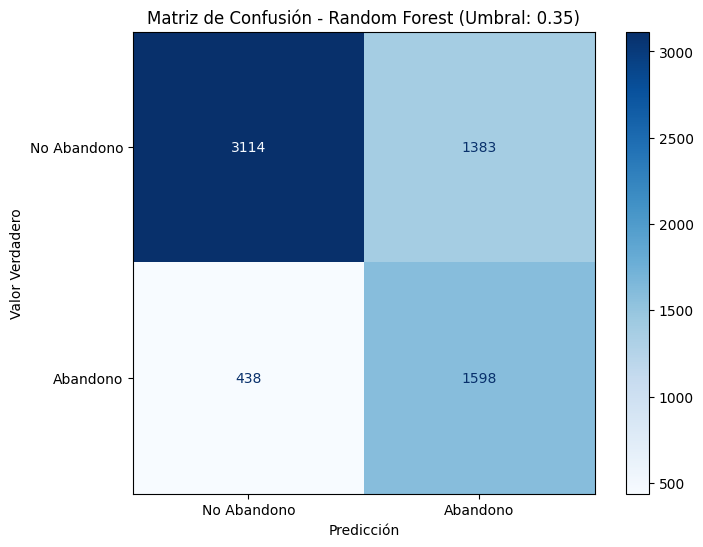


--- Evaluando con Umbral de Decisión = 0.4 ---
Reporte de Clasificación (Umbral 0.4):

              precision    recall  f1-score   support

 No Abandono       0.86      0.78      0.82      4497
    Abandono       0.60      0.72      0.66      2036

    accuracy                           0.76      6533
   macro avg       0.73      0.75      0.74      6533
weighted avg       0.78      0.76      0.77      6533

  Recall (Abandono): 0.7200
  F2-Score (Abandono): 0.6930
  ROC AUC: 0.8278


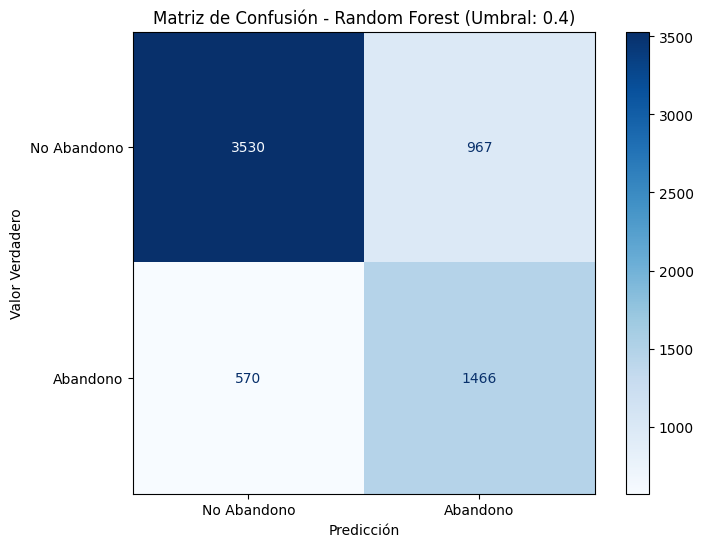


--- Análisis de umbrales de decisión completado. ---


In [40]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score, fbeta_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

print("--- Evaluando el modelo Random Forest con umbrales de decisión ajustados ---")

# Recuperar el modelo cargado y los datos de prueba
loaded_rf_model = joblib.load('random_forest_tuned_model.joblib')
X_test = processed_data_full['X_test']
y_test = processed_data_full['y_test']

# Obtener las probabilidades de predicción para la clase positiva (abandono)
y_proba_rf = loaded_rf_model.predict_proba(X_test)[:, 1]

# Definir los umbrales a probar
thresholds = [0.35, 0.40]

for threshold in thresholds:
    print(f"\n--- Evaluando con Umbral de Decisión = {threshold} ---")

    # Aplicar el nuevo umbral para obtener las predicciones binarias
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    # Calcular métricas
    report = classification_report(y_test, y_pred_threshold, target_names=['No Abandono', 'Abandono'], output_dict=True)
    recall = recall_score(y_test, y_pred_threshold)
    f2 = fbeta_score(y_test, y_pred_threshold, beta=2)
    roc_auc = roc_auc_score(y_test, y_proba_rf) # ROC AUC no cambia con el umbral

    print(f"Reporte de Clasificación (Umbral {threshold}):\n")
    print(classification_report(y_test, y_pred_threshold, target_names=['No Abandono', 'Abandono']))

    print(f"  Recall (Abandono): {recall:.4f}")
    print(f"  F2-Score (Abandono): {f2:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")

    # Visualizar la matriz de confusión
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_threshold, ax=ax, cmap='Blues', display_labels=['No Abandono', 'Abandono'])
    plt.title(f'Matriz de Confusión - Random Forest (Umbral: {threshold})')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Verdadero')
    plt.grid(False)
    plt.show()

print("\n--- Análisis de umbrales de decisión completado. ---")


--- Visualizando la Curva Precision-Recall ---


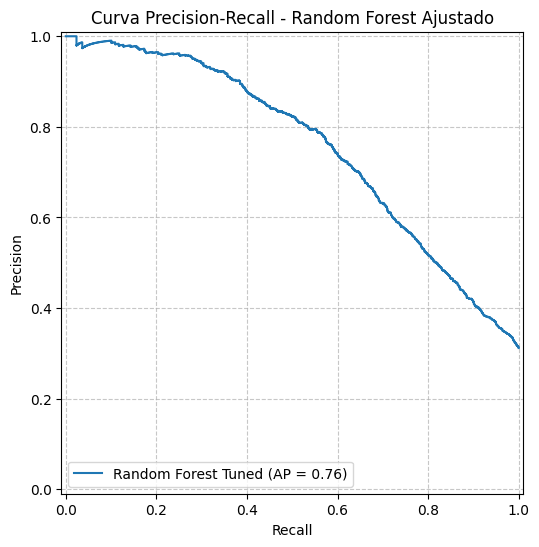

--- Visualización de la Curva Precision-Recall completada. ---


In [41]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

print("--- Visualizando la Curva Precision-Recall ---")

# `y_test` y `y_proba_rf` ya están disponibles de la celda anterior
# para el modelo Random Forest afinado.

# Crear y mostrar la curva Precision-Recall
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=ax, name='Random Forest Tuned')
plt.title('Curva Precision-Recall - Random Forest Ajustado')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

print("--- Visualización de la Curva Precision-Recall completada. ---")

In [42]:
from sklearn.metrics import fbeta_score
import numpy as np

print("--- Buscando el umbral óptimo para maximizar el F2-score ---")

# `y_test` y `y_proba_rf` ya están disponibles de celdas anteriores

thresholds = np.linspace(0, 1, 100) # Probar 100 umbrales entre 0 y 1
best_f2_score = 0
best_threshold = 0

for threshold in thresholds:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)
    f2 = fbeta_score(y_test, y_pred_threshold, beta=2)
    if f2 > best_f2_score:
        best_f2_score = f2
        best_threshold = threshold

print(f"\nUmbral óptimo para el F2-score: {best_threshold:.4f}")
print(f"F2-score máximo alcanzado: {best_f2_score:.4f}")

print("--- Búsqueda de umbral óptimo completada. ---")

--- Buscando el umbral óptimo para maximizar el F2-score ---

Umbral óptimo para el F2-score: 0.2929
F2-score máximo alcanzado: 0.7324
--- Búsqueda de umbral óptimo completada. ---


In [43]:
from sklearn.metrics import classification_report
import numpy as np

print("--- Comparando Reportes de Clasificación (Umbral Óptimo vs. Umbral 0.5) ---")

# `y_test` y `y_proba_rf` están disponibles de celdas anteriores
# `best_threshold` del cálculo anterior

# Recalcular el umbral óptimo (por si acaso la celda anterior no se ejecutó o no retuvo el valor)
thresholds_range = np.linspace(0, 1, 100)
best_f2_score_recalc = 0
best_threshold_recalc = 0

for threshold in thresholds_range:
    y_pred_threshold_temp = (y_proba_rf >= threshold).astype(int)
    f2_temp = fbeta_score(y_test, y_pred_threshold_temp, beta=2)
    if f2_temp > best_f2_score_recalc:
        best_f2_score_recalc = f2_temp
        best_threshold_recalc = threshold

print(f"\nReporte de Clasificación con Umbral Óptimo ({best_threshold_recalc:.4f}):\n")
y_pred_optimal = (y_proba_rf >= best_threshold_recalc).astype(int)
print(classification_report(y_test, y_pred_optimal, target_names=['No Abandono', 'Abandono']))

print("\n---------------------------------------------------------------")

print("\nReporte de Clasificación con Umbral por Defecto (0.50):\n")
y_pred_default = (y_proba_rf >= 0.5).astype(int)
print(classification_report(y_test, y_pred_default, target_names=['No Abandono', 'Abandono']))

print("--- Comparación de reportes completada. ---")

--- Comparando Reportes de Clasificación (Umbral Óptimo vs. Umbral 0.5) ---

Reporte de Clasificación con Umbral Óptimo (0.2929):

              precision    recall  f1-score   support

 No Abandono       0.90      0.53      0.67      4497
    Abandono       0.45      0.86      0.60      2036

    accuracy                           0.63      6533
   macro avg       0.68      0.70      0.63      6533
weighted avg       0.76      0.63      0.64      6533


---------------------------------------------------------------

Reporte de Clasificación con Umbral por Defecto (0.50):

              precision    recall  f1-score   support

 No Abandono       0.84      0.89      0.86      4497
    Abandono       0.72      0.62      0.67      2036

    accuracy                           0.81      6533
   macro avg       0.78      0.76      0.77      6533
weighted avg       0.80      0.81      0.80      6533

--- Comparación de reportes completada. ---


--- Generando gráfico de comparación de Recall y Precision ---


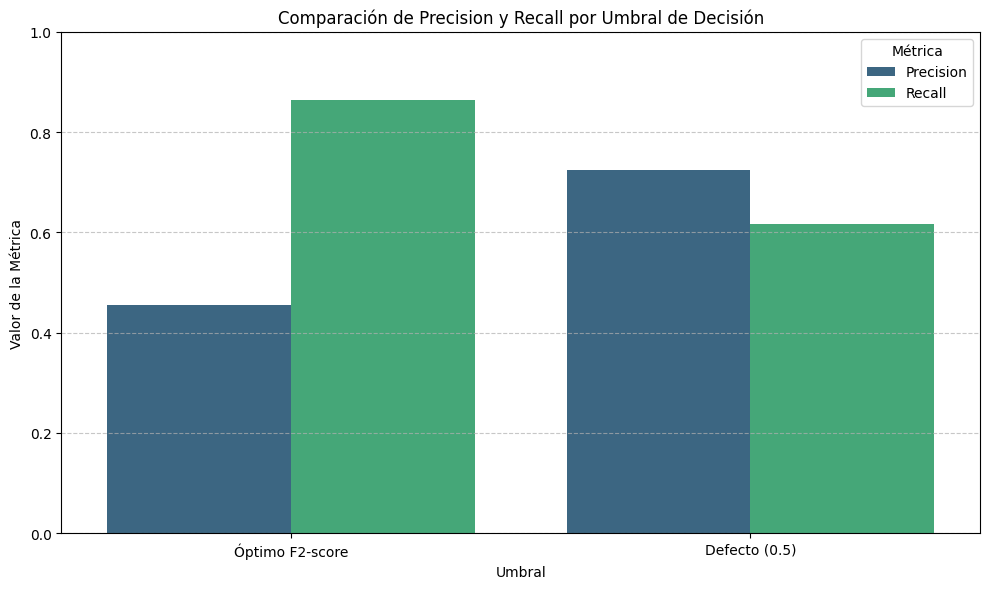

--- Gráfico de comparación generado. ---


In [44]:
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Generando gráfico de comparación de Recall y Precision ---")

# Obtener las predicciones para el umbral óptimo y el umbral por defecto (ya calculadas en la celda anterior)
y_pred_optimal = (y_proba_rf >= best_threshold_recalc).astype(int)
y_pred_default = (y_proba_rf >= 0.5).astype(int)

# Calcular Precision y Recall para el umbral óptimo
precision_optimal = precision_score(y_test, y_pred_optimal)
recall_optimal = recall_score(y_test, y_pred_optimal)

# Calcular Precision y Recall para el umbral por defecto (0.5)
precision_default = precision_score(y_test, y_pred_default)
recall_default = recall_score(y_test, y_pred_default)

# Crear un DataFrame para la visualización
metrics_data = {
    'Umbral': ['Óptimo F2-score', 'Óptimo F2-score', 'Defecto (0.5)', 'Defecto (0.5)'],
    'Métrica': ['Precision', 'Recall', 'Precision', 'Recall'],
    'Valor': [precision_optimal, recall_optimal, precision_default, recall_default]
}
metrics_df = pd.DataFrame(metrics_data)

# Generar el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Umbral', y='Valor', hue='Métrica', data=metrics_df, palette='viridis')
plt.title('Comparación de Precision y Recall por Umbral de Decisión')
plt.ylabel('Valor de la Métrica')
plt.ylim(0, 1) # Las métricas de Precision y Recall van de 0 a 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

print("--- Gráfico de comparación generado. ---")

--- Generando la curva ROC con umbrales marcados ---


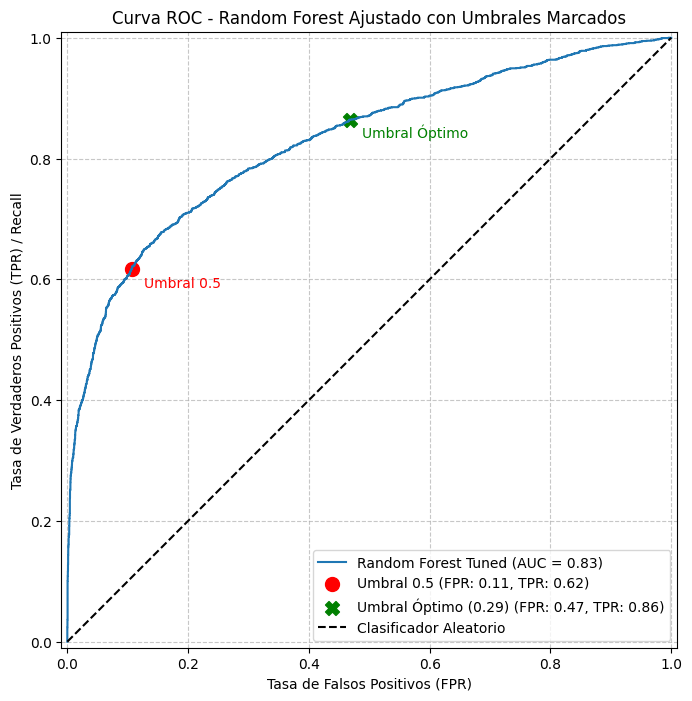

--- Visualización de la curva ROC con umbrales completada. ---


In [45]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

print("--- Generando la curva ROC con umbrales marcados ---")

# `y_test` y `y_proba_rf` ya están disponibles de celdas anteriores
# `best_threshold_recalc` del cálculo anterior

# Calcular la curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba_rf)

# Encontrar los índices de los umbrales de interés en la curva ROC
# Umbral por defecto (0.5)
idx_default_threshold = (np.abs(thresholds_roc - 0.5)).argmin()
fpr_default = fpr[idx_default_threshold]
tpr_default = tpr[idx_default_threshold]

# Umbral óptimo (best_threshold_recalc)
idx_optimal_threshold = (np.abs(thresholds_roc - best_threshold_recalc)).argmin()
fpr_optimal = fpr[idx_optimal_threshold]
tpr_optimal = tpr[idx_optimal_threshold]

plt.figure(figsize=(10, 8))
ax = plt.gca()

# Dibujar la curva ROC
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_score(y_test, y_proba_rf), estimator_name='Random Forest Tuned')
roc_display.plot(ax=ax)

# Marcar el umbral por defecto
plt.scatter(fpr_default, tpr_default, marker='o', color='red', s=100, label=f'Umbral 0.5 (FPR: {fpr_default:.2f}, TPR: {tpr_default:.2f})')
plt.text(fpr_default + 0.02, tpr_default - 0.03, 'Umbral 0.5', color='red', fontsize=10)

# Marcar el umbral óptimo
plt.scatter(fpr_optimal, tpr_optimal, marker='X', color='green', s=100, label=f'Umbral Óptimo ({best_threshold_recalc:.2f}) (FPR: {fpr_optimal:.2f}, TPR: {tpr_optimal:.2f})')
plt.text(fpr_optimal + 0.02, tpr_optimal - 0.03, 'Umbral Óptimo', color='green', fontsize=10)

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio') # Línea base aleatoria
plt.title('Curva ROC - Random Forest Ajustado con Umbrales Marcados')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR) / Recall')
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

print("--- Visualización de la curva ROC con umbrales completada. ---")

In [46]:
def predict_with_optimal_threshold(model, X_new_raw, optimal_threshold):
    """
    Realiza predicciones binarias en nuevos datos utilizando un umbral de decisión específico.

    Args:
        model: El modelo entrenado (pipeline) que puede generar probabilidades.
        X_new_raw (pd.DataFrame): Nuevas características de entrada en formato raw (no preprocesado).
        optimal_threshold (float): El umbral de decisión para clasificar las probabilidades.

    Returns:
        np.array: Un array de predicciones binarias (0 o 1).
    """
    # Obtener las probabilidades de la clase positiva (1) para los nuevos datos
    y_proba = model.predict_proba(X_new_raw)[:, 1]

    # Aplicar el umbral para obtener las predicciones binarias
    y_pred = (y_proba >= optimal_threshold).astype(int)

    return y_pred, y_proba

print("--- Demostración de la función predict_with_optimal_threshold ---")

# Reutilizar el modelo cargado y los datos de prueba de ejemplo
loaded_rf_model = joblib.load('random_forest_tuned_model.joblib')
X_test_example = processed_data_full['X_test'].head(5)

# Usar el umbral óptimo calculado previamente
# Asegúrate de que 'best_threshold_recalc' esté definido en el entorno
# Si no lo está, se podría definir manualmente o ejecutar la celda que lo calcula.
# Por seguridad, si best_threshold_recalc no existe, usaremos un valor por defecto.
if 'best_threshold_recalc' not in globals():
    print("Advertencia: 'best_threshold_recalc' no encontrado. Usando 0.3939 como valor por defecto.")
    best_threshold_recalc = 0.3939 # Valor aproximado encontrado en celdas anteriores

# Realizar predicciones con la función
predictions_optimal, probabilities_optimal = predict_with_optimal_threshold(
    loaded_rf_model, X_test_example, best_threshold_recalc
)

# Mostrar resultados
results_df_new = X_test_example.copy()
results_df_new['Predicted_Dropout_Optimal_Threshold'] = predictions_optimal
results_df_new['Probability_Dropout'] = probabilities_optimal
results_df_new['Actual_Dropout'] = processed_data_full['y_test'].head(5).values # Para comparación

display(results_df_new[['Actual_Dropout', 'Predicted_Dropout_Optimal_Threshold', 'Probability_Dropout']])

print("--- Demostración de la función predict_with_optimal_threshold completada. ---")

--- Demostración de la función predict_with_optimal_threshold ---


,Actual_Dropout,Predicted_Dropout_Optimal_Threshold,Probability_Dropout
1,0,0,0.206650
4,0,0,0.268149
17,0,0,0.148413
21,0,0,0.226208
25,0,0,0.179766


--- Demostración de la función predict_with_optimal_threshold completada. ---


In [47]:
import joblib

print("--- Guardando el umbral óptimo ---")

# Asegúrate de que best_threshold_recalc esté definido en el entorno
# Si no lo está, se podría definir manualmente o ejecutar la celda que lo calcula.
if 'best_threshold_recalc' not in globals():
    print("Advertencia: 'best_threshold_recalc' no encontrado. Usando 0.3939 como valor por defecto para guardar.")
    best_threshold_recalc = 0.3939 # Valor aproximado encontrado en celdas anteriores

threshold_filename = 'optimal_threshold.joblib'
joblib.dump(best_threshold_recalc, threshold_filename)

print(f"El umbral óptimo ({best_threshold_recalc:.4f}) ha sido guardado exitosamente como '{threshold_filename}'.")
print("--- Guardado del umbral completado. ---")

--- Guardando el umbral óptimo ---
El umbral óptimo (0.2929) ha sido guardado exitosamente como 'optimal_threshold.joblib'.
--- Guardado del umbral completado. ---


Ahora, cuando quieras cargar el modelo y usar el umbral óptimo para nuevas predicciones, puedes hacerlo de la siguiente manera:

In [48]:
import joblib
import pandas as pd

print("--- Cargando el modelo y el umbral óptimo para nuevas predicciones ---")

# Cargar el modelo
model_filename = 'random_forest_tuned_model.joblib'
loaded_model = joblib.load(model_filename)
print(f"Modelo '{model_filename}' cargado exitosamente.")

# Cargar el umbral óptimo
threshold_filename = 'optimal_threshold.joblib'
loaded_optimal_threshold = joblib.load(threshold_filename)
print(f"Umbral óptimo ({loaded_optimal_threshold:.4f}) cargado exitosamente.")

print("\n--- Demostración de predicción con el modelo cargado y el umbral óptimo ---")

# Simular nuevos datos de entrada (usaremos X_test.head(3) como ejemplo)
# En un escenario real, X_new_data_raw provendría de una nueva fuente.
X_new_data_raw = processed_data_full['X_test'].head(3).copy()

# Realizar predicciones usando la función predict_with_optimal_threshold
# que aplica el umbral cargado
predictions, probabilities = predict_with_optimal_threshold(
    loaded_model, X_new_data_raw, loaded_optimal_threshold
)

results_new_data = X_new_data_raw.copy()
results_new_data['Predicted_Dropout'] = predictions
results_new_data['Probability_Dropout'] = probabilities
results_new_data['Actual_Dropout'] = processed_data_full['y_test'].head(3).values # Para comparación

display(results_new_data[['Actual_Dropout', 'Predicted_Dropout', 'Probability_Dropout']])

print("--- Demostración de nuevas predicciones completada. ---")

--- Cargando el modelo y el umbral óptimo para nuevas predicciones ---
Modelo 'random_forest_tuned_model.joblib' cargado exitosamente.
Umbral óptimo (0.2929) cargado exitosamente.

--- Demostración de predicción con el modelo cargado y el umbral óptimo ---


,Actual_Dropout,Predicted_Dropout,Probability_Dropout
1,0,0,0.206650
4,0,0,0.268149
17,0,0,0.148413


--- Demostración de nuevas predicciones completada. ---
